============================================================
Cervical Cancer Early Prediction — Dual Experiment Pipeline<br>
宫颈癌早期预测 — 双实验流水线<br>
Experiment A: Demographic + Behavioral Features Only<br>
实验A：仅人口统计与行为特征<br>
Experiment B: + Basic Clinical Screening (Hinselmann, Schiller, Citology)<br>
实验B：+ 基础临床筛查（Hinselmann、Schiller、细胞学）<br>
Core: Hybrid Soft-Voting Ensemble Models<br>
核心：混合软投票集成模型<br>
============================================================


### ============================================================
### Cervical Cancer Early Prediction — Dual Experiment Pipeline
### 宫颈癌早期预测——双实验流程
### <br>
### PURPOSE:
###   This pipeline trains and evaluates hybrid soft-voting ensemble classifiers to predict the need for a cervical biopsy, using two experimental settings that differ in how much clinical information is assumed to be available at prediction time.
### 该流程训练和评估混合软投票集成分类器，以预测是否需要进行宫颈活检，使用两种实验设置，这两种设置的区别在于预测时假设有多少临床信息可用。
### <br>
### EXPERIMENT OVERVIEW:
###   Experiment A (ExpA_EarlyOnly):
###       Uses only demographic + behavioral/self-reported risk factors (e.g., age, smoking, STD history).  Simulates a questionnaire-only early-screening scenario — no lab or clinical tests required.
### 实验概述：
### 实验 A (ExpA_EarlyOnly)：
### 仅使用人口统计学和行为/自我报告的风险因素（例如，年龄、吸烟、性传播疾病史）。模拟仅通过问卷调查进行的早期筛查场景——无需实验室或临床检测。
### <br>
###   Experiment B (ExpB_WithScreening):
###       Adds three routine (non-biopsy) screening test results:
- ###          Hinselmann  — colposcopy visual exam
- ###          Schiller    — iodine-stain (Schiller's test)
- ###          Citology    — Pap-smear cytology
###       Simulates a post-screening triage scenario: "the patient has had basic screening; should we proceed to biopsy?"
###       NOTE: ExpB is NOT an early-prediction setting — these three tests are strong proxies for the target label and significantly inflate performance metrics.
### 实验 B (ExpB_WithScreening)：
### 添加三项常规（非活检）筛查结果：
- ### Hinselmann 试验 — 阴道镜检查
- ### Schiller 试验 — 碘染色（席勒氏试验）
- ### 细胞学检查 — 巴氏涂片细胞学检查
### 模拟筛查后的分诊场景：“患者已完成基础筛查；是否需要进行活检？”
### 注意：ExpB 并非早期预测模型——这三项检查结果与目标诊断密切相关，会显著提高性能指标。
### <br>
### TARGET VARIABLE:
###   Biopsy (binary: 1 = positive / biopsy recommended, 0 = negative)
### 目标变量：
### 活检（二元变量：1 = 阳性/建议活检，0 = 阴性）
### <br>
### PIPELINE STAGES:
- ###   Phase 1 — Single-model baseline (SMOTE, no tuning)
- ###   Phase 2 — Feature selection (RFE + tree importance)
- ###   Phase 3 — Untuned hybrid soft-voting ensemble models
- ###   Phase 4 — Hyperparameter-tuned hybrid models + stacking
### 流程阶段：

- ### 第一阶段 — 单模型基线（SMOTE，未调优）

- ### 第二阶段 — 特征选择（RFE + 树重要性）

- ### 第三阶段 — 未调优的混合软投票集成模型

- ### 第四阶段 — 超参数调优的混合模型 + 堆叠
### <br>
### OUTPUT:
- ###    PNG visualizations (ROC curves, confusion matrices, etc.)
- ###    CSV summary tables
- ###    SHAP interpretability plots (if the `shap` package is installed)
### 输出：
- ### PNG 可视化图表（ROC 曲线、混淆矩阵等）
- ### CSV 汇总表
- ### SHAP 可解释性图（如果已安装 `shap` 包）
### ============================================================

# ─────────────────────────────────────────────────────────────
# SECTION 1: IMPORTS & ENVIRONMENT SETUP  / 导入与环境设置
# ─────────────────────────────────────────────────────────────

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import os
from pathlib import Path
import time
import warnings
warnings.filterwarnings("ignore")   # Suppress sklearn/XGBoost deprecation noise

# Resolve the working directory so the script can be run from
# any location (Jupyter, IDE, or command line).
BASE_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
OUTPUT_DIR = BASE_DIR / "pipeline_output"   # Fallback directory for permission-blocked writes
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Helper: Safe CSV Writer ───────────────────────────────────
def safe_save_csv(df, fname):
    """
    Write a DataFrame to CSV.  If a PermissionError is raised
    (e.g., the script's directory is read-only), the file is
    redirected to OUTPUT_DIR instead of failing silently.

    Parameters
    ----------
    df    : pd.DataFrame  — data to save
    fname : str           — target filename (relative)

    Returns
    -------
    pathlib.Path of the file actually written
    """
    target = BASE_DIR / fname
    try:
        df.to_csv(target)
        return target
    except PermissionError:
        fallback = OUTPUT_DIR / fname
        fallback.parent.mkdir(parents=True, exist_ok=True)
        print(f"    PermissionError saving CSV {fname}; writing to {fallback}")
        df.to_csv(fallback)
        return fallback

# ── Scikit-learn: Model Training & Evaluation ────────────────
from sklearn.model_selection import (
    train_test_split,      # Stratified train/test split
    GridSearchCV,          # Exhaustive hyperparameter search
    RandomizedSearchCV,    # Randomized hyperparameter search (faster for large spaces)
    StratifiedKFold        # K-fold CV that preserves class ratios
)
from sklearn.preprocessing import StandardScaler     # Zero-mean, unit-variance scaling
from sklearn.feature_selection import RFE            # Recursive Feature Elimination
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score,               # ← PRIMARY metric for medical screening (minimise false negatives)
    f1_score, 
    roc_auc_score, 
    average_precision_score,    # Area under Precision-Recall curve (better for imbalanced data)
    confusion_matrix, 
    roc_curve
)

# ── Classifiers ───────────────────────────────────────────────
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    VotingClassifier,       # Soft-voting ensemble (averages predicted probabilities)
    StackingClassifier,     # Meta-learner stacking (trains a second-level model on base outputs)
)
from sklearn.linear_model import LogisticRegression     # Used as stacking meta-learner
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

# ── Class Imbalance Handling ──────────────────────────────────
# BorderlineSMOTE oversamples only minority-class samples that
# lie near the decision boundary ("borderline" samples), which
# produces more informative synthetic examples than vanilla SMOTE.
from imblearn.over_sampling import BorderlineSMOTE

# ── Visualization ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Monkey-Patch: Safe Figure Saver ──────────────────────────
# Redirects plt.savefig() to OUTPUT_DIR when a PermissionError
# is raised, avoiding silent failures in restricted environments.
if not hasattr(plt, '_savefig_orig'):
    plt._savefig_orig = plt.savefig

    def safe_save_fig(fname, **kwargs):
        """
        Drop-in replacement for plt.savefig that falls back to
        OUTPUT_DIR if the primary path is not writable.
        """
        target = BASE_DIR / fname
        try:
            return plt._savefig_orig(target, **kwargs)
        except PermissionError:
            fallback = OUTPUT_DIR / fname
            fallback.parent.mkdir(parents=True, exist_ok=True)
            print(f"    PermissionError saving figure {fname}; writing to {fallback}")
            return plt._savefig_orig(fallback, **kwargs)

    plt.savefig = safe_save_fig

# ── Optional: SHAP Interpretability ──────────────────────────
# SHAP (SHapley Additive exPlanations) quantifies each feature's
# contribution to individual predictions.  It is optional;
# install with `pip install shap` to enable.
try:
    import shap
    SHAP_AVAILABLE = True
except ModuleNotFoundError:
    SHAP_AVAILABLE = False
    print("Warning: shap not found. Skipping SHAP analysis.")

# ─────────────────────────────────────────────────────────────
# SECTION 2: FEATURE GROUP DEFINITIONS  / 特征组定义与实验配置
# ─────────────────────────────────────────────────────────────

### WHY TWO FEATURE SETS?
###   The fundamental research question is: how early can we predict biopsy need — and what is the cost of restricting the model to information available before any clinical test?
### 为什么需要两组特征？

### 根本的研究问题是：我们能多早预测是否需要进行活检？如果将模型限制在任何临床检查之前可获得的信息，代价是什么？
### <br>
###   ExpA answers: "Can a questionnaire alone flag high-risk women?"
###   ExpB answers: "How much better can we do once three routine screening tests have already been performed?"
### 实验A的回答：“仅凭问卷调查能否识别出高危女性？”

### 实验B的回答：“在已经进行了三项常规筛查之后，我们还能做得更好吗？”
### <br>
### IMPORTANT CAVEAT FOR ExpB:
###   Hinselmann, Schiller, and Citology are themselves diagnostic tests whose primary purpose is to detect cervical abnormalities.
###   Including them is therefore NOT early prediction — it is post-screening triage/decision support.  Researchers should be explicit about this distinction when reporting results.
### ExpB 的重要注意事项：

### Hinselmann 试验、Schiller 试验和 Citology 试验本身都是诊断性试验，其主要目的是检测宫颈异常。

### 因此，纳入这些试验并非早期预测，而是筛查后的分诊/决策支持。研究人员在报告结果时应明确指出这一点。


In [2]:
# ── Experiment A: Questionnaire / Demographic Features Only ──
EXP_A_FEATURES = [
    # ─ Demographic ─────────────────────────────────────────
    'Age',

    # ─ Sexual History ──────────────────────────────────────
    'Number of sexual partners',    # Known HPV risk factor
    'First sexual intercourse',     # Age at first intercourse

    # ─ Reproductive History ────────────────────────────────
    'Num of pregnancies',

    # ─ Smoking (major carcinogen co-factor) ────────────────
    'Smokes',                       # Binary flag
    'Smokes (years)',               # Duration
    'Smokes (packs/year)',          # Pack-year exposure

    # ─ Hormonal Contraceptives (long-term use is a risk factor) ─
    'Hormonal Contraceptives',      # Binary flag
    'Hormonal Contraceptives (years)',

    # ─ IUD (intrauterine device — protective effect debated) ─
    'IUD',
    'IUD (years)',

    # ─ STD History (HPV is the primary cervical cancer cause) ─
    'STDs',                                   # Any STD: binary flag
    'STDs (number)',                          # Count of distinct STDs
    'STDs:condylomatosis',                    # Genital warts (HPV-related)
    'STDs:vaginal condylomatosis',
    'STDs:vulvo-perineal condylomatosis',
    'STDs:syphilis',
    'STDs:pelvic inflammatory disease',
    'STDs:genital herpes',
    'STDs:molluscum contagiosum',
    'STDs:HIV',                               # Immunosuppression dramatically raises risk
    'STDs:Hepatitis B',
    'STDs:HPV',                               # Direct causal agent

    # ─ Prior Diagnoses ─────────────────────────────────────
    'STDs: Number of diagnosis',
    'Dx:Cancer',                              # Previous cancer diagnosis
    'Dx:CIN',                                 # Cervical intraepithelial neoplasia (precursor)
    'Dx:HPV',                                 # HPV-positive diagnosis
    'Dx',                                     # General diagnosis flag
]

# ── Experiment B: ExpA + Basic Screening Results ─────────────
EXP_B_EXTRA = [
    'Hinselmann',   # Colposcopy visual exam result (binary)
    'Schiller',     # Schiller's iodine-stain test result (binary)
    'Citology',     # Pap-smear cytology result (binary)
]
EXP_B_FEATURES = EXP_A_FEATURES + EXP_B_EXTRA

# ── Biopsy is the gold-standard target label ─────────────────
TARGET = "Biopsy"   # 1 = biopsy recommended/positive, 0 = negative

# ── Dispatch table for the main experiment loop ───────────────
EXPERIMENT_CONFIGS = {
    "ExpA_EarlyOnly":     EXP_A_FEATURES,   # Questionnaire only
    "ExpB_WithScreening": EXP_B_FEATURES,   # + clinical screens
}

# ─────────────────────────────────────────────────────────────
# SECTION 3: SHARED HELPER FUNCTIONS
# ─────────────────────────────────────────────────────────────


In [3]:
def evaluate_model(model, X_test, y_test, threshold=0.3):
    """
    Evaluate a fitted classifier on a held-out test set.

    A custom probability threshold (default 0.3, not the standard
    0.5) is used to boost recall — in a medical screening context,
    missing a true positive (false negative) is far more costly
    than a false alarm (false positive).

    Parameters
    ----------
    model     : fitted sklearn-compatible classifier
    X_test    : array-like, shape (n_samples, n_features)
    y_test    : array-like, shape (n_samples,)
    threshold : float — probability cut-off for positive class

    Returns
    -------
    metrics : dict   — Accuracy, Precision, Recall, F1, AUC, PR-AUC
    y_pred  : ndarray — binary predictions at the given threshold
    y_prob  : ndarray — raw positive-class probabilities
    """
    y_prob = model.predict_proba(X_test)[:, 1]          # P(positive class)
    y_pred = (y_prob >= threshold).astype(int)           # Apply custom threshold

    metrics = {
        "Accuracy":  round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "Recall":    round(recall_score(y_test, y_pred, zero_division=0), 4),
        "F1":        round(f1_score(y_test, y_pred, zero_division=0), 4),
        # AUC is threshold-independent (ranks positives above negatives)
        "AUC":       round(roc_auc_score(y_test, y_prob), 4),
        # PR-AUC is more informative than ROC-AUC under class imbalance
        "PR-AUC":    round(average_precision_score(y_test, y_prob), 4),
    }
    return metrics, y_pred, y_prob


def replace_outliers_iqr(series):
    """
    Winsorise extreme values in a numeric Series using the
    1.5 * IQR rule (equivalent to Tukey fences).

    Values below Q1 - 1.5 * IQR are clipped to that lower fence;
    values above Q3 + 1.5 * IQR are clipped to the upper fence.
    This preserves all rows (no data loss) while limiting the
    influence of extreme outliers on distance-based models
    (KNN, SVC) and tree impurity calculations.

    Parameters
    ----------
    series : pd.Series — a single numeric column

    Returns
    -------
    pd.Series with outliers clipped to Tukey fence values
    """
    Q1  = series.quantile(0.25)
    Q3  = series.quantile(0.75)
    IQR = Q3 - Q1
    return series.clip(lower=Q1 - 1.5 * IQR,
                       upper=Q3 + 1.5 * IQR)


def print_section(title):
    """Print a visually distinct section header to stdout."""
    print("\n" + "=" * 65)
    print(f"  {title}")
    print("=" * 65)


def get_pos_weight(y_train):
    """
    Compute the XGBoost `scale_pos_weight` parameter.

    XGBoost uses this ratio to up-weight the minority (positive)
    class during training, compensating for class imbalance
    without requiring external resampling.

    Formula: count(negative) / count(positive)

    The max(..., 1) guard prevents division-by-zero if the
    training fold happens to contain no positive samples.

    Parameters
    ----------
    y_train : array-like of binary labels

    Returns
    -------
    float — weight ratio for XGBoost's scale_pos_weight
    """
    return (y_train == 0).sum() / max((y_train == 1).sum(), 1)


def cv_stability_compare(models_dict, X, y, cv=5, scoring='recall'):
    """
    Compare model stability using stratified k-fold cross-validation.

    Reports mean ± std of the chosen metric across folds, which
    reveals whether a model's test-set performance is reproducible
    or the result of a lucky random split.

    Parameters
    ----------
    models_dict : dict {name: fitted_model}
    X           : feature matrix (full dataset, pre-scaled)
    y           : target vector
    cv          : int — number of CV folds
    scoring     : str — sklearn scoring string (default: 'recall')

    Returns
    -------
    dict {name: {'mean': float, 'std': float, 'cv_scores': ndarray}}
    """
    results = {}
    kfold = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    for name, model in models_dict.items():
        scores = cross_val_score(model, X, y, cv=kfold,
                                 scoring=scoring, n_jobs=-1)
        results[name] = {
            'mean':      round(scores.mean(), 4),
            'std':       round(scores.std(),  4),
            'cv_scores': scores,
        }
        print(f"  {name}: {scoring} = {scores.mean():.4f} ± {scores.std():.4f}")
    return results

# ─────────────────────────────────────────────────────────────
# SECTION 4: DATA LOADING & PREPROCESSING / 数据加载和预处理
# ─────────────────────────────────────────────────────────────

In [4]:
print_section("LOADING & PREPROCESSING DATA")

# ── 4.1  Load Raw Dataset ────────────────────────────────────
# Source: UCI Cervical Cancer (Risk Factors) Dataset
# 858 rows × 36 features; missing values are encoded as '?'
df_raw = pd.read_csv(BASE_DIR / "kag_risk_factors_cervical_cancer.csv")
df_raw = df_raw.replace("?", np.nan)   # Standardise missing-value representation

# ── 4.2  Drop Uninformative Columns ─────────────────────────
# These columns are excluded for two reasons:
#   • 'STDs: Time since first/last diagnosis' — >80 % missing,
#     imputation would introduce substantial noise.
#   • 'STDs:cervical condylomatosis' and 'STDs:AIDS' — all-zero
#     or near-zero variance in this dataset (zero-information).
drop_cols = [
    'STDs: Time since first diagnosis',
    'STDs: Time since last diagnosis',
    'STDs:cervical condylomatosis',
    'STDs:AIDS',
]
df_raw = df_raw.drop(
    columns=[c for c in drop_cols if c in df_raw.columns],
    errors='ignore'   # Silently skip columns that don't exist
)

# ── 4.3  Type Coercion ───────────────────────────────────────
# All columns should be numeric; coerce converts any remaining
# non-numeric strings to NaN (which are then filled in 4.4).
df_raw = df_raw.apply(pd.to_numeric, errors='coerce')

# ── 4.4  Missing Value Imputation ────────────────────────────
# Strategy: column-wise MEDIAN imputation.
# The median is preferred over the mean because:
#   • Many columns are heavily right-skewed (count variables).
#   • The median is robust to the outliers we haven't yet removed.
# A single-pass median imputation (rather than iterative imputation)
# is acceptable here given that missingness is predominantly MCAR
# (Missing Completely At Random).
df_raw = df_raw.fillna(df_raw.median())

# ── 4.5  Outlier Winsorisation ───────────────────────────────
# IQR-based clipping on continuous (non-binary) columns.
# Binary / count columns are intentionally excluded because
# clipping a 0/1 flag or a small integer count is meaningless.
continuous_cols = [
    'Age',
    'Number of sexual partners',
    'First sexual intercourse',
    'Smokes (packs/year)',
    'Num of pregnancies',
    'IUD (years)',
]
for col in continuous_cols:
    if col in df_raw.columns:
        df_raw[col] = replace_outliers_iqr(df_raw[col])

print(f"Dataset shape after cleaning: {df_raw.shape}")
print(f"Target ({TARGET}) distribution: {df_raw[TARGET].value_counts().to_dict()}")


  LOADING & PREPROCESSING DATA
Dataset shape after cleaning: (858, 32)
Target (Biopsy) distribution: {0: 803, 1: 55}


# ─────────────────────────────────────────────────────────────
# SECTION 5: RESULT STORES (SHARED ACROSS EXPERIMENTS) / 结果存储（跨实验共享）
# ─────────────────────────────────────────────────────────────

### These dictionaries accumulate outputs from each experiment so that cross-experiment visualisations can be built after the main loop finishes.
### 这些字典会累积每个实验的输出，以便在主循环结束后构建跨实验可视化。

In [5]:
# ============================================================
# MASTER RESULTS STORE
# ============================================================
# Stores results for every experiment × phase for final comparison

all_results      = {}   # {exp_name: {phase_label: DataFrame of metrics}}
all_roc_data     = {}   # {exp_name: {phase_label: {model_name: (fpr, tpr, auc)}}}
all_best_models  = {}   # {exp_name: (best_model_name, fitted_model_object)}
all_tuned_models = {}   # {exp_name: {model_name: fitted_model}}
all_X_test       = {}   # {exp_name: scaled test feature matrix}
all_y_test       = {}   # {exp_name: test target vector}
all_scalers      = {}   # {exp_name: fitted StandardScaler}
all_selected     = {}   # {exp_name: list of selected feature names}

# ─────────────────────────────────────────────────────────────
# SECTION 6: MAIN EXPERIMENT LOOP / 主实验循环
# ─────────────────────────────────────────────────────────────

### Each of the four pipeline phases is encapsulated in its own function.  This separates concerns, makes unit-testing straightforward, and keeps the main experiment loop (Section 7) a thin, readable orchestrator with no inline logic.
### <br>
### Dependency flow between phases:
###
###   run_phase1_baseline(exp_name, X_full, y_full)
###       └─ returns: scaler, X_train_s, y_train, X_test_s, y_test,
###                   metrics_df, roc_data
### <br>
###   run_phase2_feature_selection(exp_name, X_full, X_train_s, ##y_train)
###       └─ returns: selected feature list, importances Series
### <br>
###   run_phase3_hybrid_models(exp_name, df_raw, selected, y_full)
###       └─ returns: scaler3, X_te3_s, y_test3, models_dict,
###                   metrics_df, roc_data, recall_scores
### <br>
###   run_phase4_tuned_hybrids(exp_name, X_tr3_bal, y_tr3_bal,
###                             X_te3_s, y_test3, recall_scores, pw3)
###       └─ returns: tuned_models dict, metrics_df, roc_data
### ─────────────────────────────────────────────────────────────
### 四个流水线阶段分别封装在各自的函数中。这实现了关注点分离，简化了单元测试，并使主实验循环（第 7 节）保持简洁易读，不包含任何内联逻辑。
### 各阶段之间的依赖关系：
### run_phase1_baseline(exp_name, X_full, y_full)
### └─ 返回值：scaler、X_train_s、y_train、X_test_s、y_test、
### metrics_df、roc_data
### run_phase2_feature_selection(exp_name, X_full, X_train_s, ##y_train)
### └─ 返回值：选定的特征列表、重要性序列
### run_phase3_hybrid_models(exp_name, df_raw, selected, y_full)
### └─ 返回值：scaler3、X_te3_s、y_test3、models_dict、
### metrics_df、roc_data、recall_scores
### run_phase4_tuned_hybrids(exp_name, X_tr3_bal, y_tr3_bal,
### X_te3_s, y_test3, recall_scores, pw3)
### └─ 返回值：tuned_models dict、metrics_df、roc_data


### Phase 1 — Single-Model Baseline### 
### Establishes per-classifier reference performance using all available features, BorderlineSMOTE oversampling, and default (untuned) hyperparameters.
### <br>
### Steps
### -----
- ### 1. Stratified 80/20 train/test split.
- ### 2. StandardScaler fitted on training data only (no leakage).
- ### 3. BorderlineSMOTE applied to the scaled training set to address the ~6 % class imbalance.
- ### 4. Four classifiers trained and evaluated:
      ### SVC   — probability=True enables predict_proba();
      ### class_weight
      - ### compensates for imbalance within the model itself.
      ### KNN   — k=5 default; no built-in class weighting.
      ### RF    — class_weight='balanced' uses inverse-frequency weights.
      ### XGBoost — scale_pos_weight = neg_count / pos_count
### <br> 
### Parameters
### ----------
### exp_name : str   — experiment identifier (used in print output)
### X_full   : pd.DataFrame — full feature matrix for thi experiment
### y_full   : pd.Series    — full target vector (Biopsy labels)
### <br>
### Returns
### -------
### split   : dict with keys X_train_s, y_train, X_test_s, y_test,
  - ### scaler — the fitted scaler and split arrays needed by Phase 2 (feature selection uses X_train_s / y_train).
### results : pd.DataFrame — metrics (rows=models, cols=metrics)
### roc     : dict {model_name: (fpr, tpr, auc)}
### 第一阶段 — 单模型基线 ###
### 使用所有可用特征、BorderlineSMOTE 过采样和默认（未调优）超参数，建立每个分类器的参考性能。
### 步骤
### -----
- ### 1. 分层 80/20 训练/测试集划分。
- ### 2. 仅在训练数据上拟合 StandardScaler（无泄漏）。
- ### 3. 对缩放后的训练集应用 BorderlineSMOTE，以解决约 6% 的类别不平衡问题。
- ### 4. 训练并评估四个分类器：
### SVC — probability=True 启用 predict_proba()；
### class_weight
- ### 用于补偿模型内部的类别不平衡。
### KNN — 默认 k=5；无内置类别加权。
### RF — class_weight='balanced' 使用逆频率权重。
### XGBoost — scale_pos_weight = neg_count / pos_count
### 参数
### ----------
### exp_name : str — 实验标识符（用于打印输出）
### X_full : pd.DataFrame — 此实验的完整特征矩阵
### y_full : pd.Series — 完整的目标向量（活检标签）
### 返回值
### -------
### split : 字典，键为 X_train_s, y_train, X_test_s, y_test,
- ### scaler — 第二阶段所需的拟合缩放器和 split 数组（特征选择使用 X_train_s / y_train）。
### results : pd.DataFrame — 指标（行=模型，列=指标）
### roc : 字典 {model_name: (fpr, tpr, auc)}

In [21]:
def run_phase1_baseline(exp_name, X_full, y_full):
    print(f"\n  --- [{exp_name}] PHASE 1: Single Model Baseline ---")

    # ── 1a. Stratified train/test split (80 / 20) ────────────
    X_train, X_test, y_train, y_test = train_test_split(
        X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
    )

    # ── 1b. Feature scaling (fit on train, apply to test) ─────
    # Fitting on the full dataset would leak test-set statistics.
    scaler    = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    # ── 1c. BorderlineSMOTE oversampling ──────────────────────
    # Synthesises minority samples only near the decision boundary,
    # producing more informative examples than vanilla SMOTE.
    # Applied exclusively to the training set.
    smote              = BorderlineSMOTE(random_state=42)
    X_tr_bal, y_tr_bal = smote.fit_resample(X_train_s, y_train)

    # ── 1d. Define and train baseline models ──────────────────
    pw = get_pos_weight(y_train)   # XGBoost class-imbalance weight
    base_models = {
        "SVC":          SVC(
                            probability=True,        # Required for predict_proba()
                            class_weight='balanced', # Inverse-frequency weighting
                            random_state=42
                        ),
        "KNN":          KNeighborsClassifier(),      # Default k=5; no class weighting
        "RandomForest": RandomForestClassifier(
                            class_weight='balanced',
                            random_state=42
                        ),
        "XGBoost":      XGBClassifier(
                            scale_pos_weight=pw,     # Up-weights minority class
                            eval_metric='logloss',   # Suppresses default warning
                            random_state=42
                        ),
    }

    res, roc = {}, {}
    for name, model in base_models.items():
        model.fit(X_tr_bal, y_tr_bal)
        metrics, _, y_prob = evaluate_model(model, X_test_s, y_test)
        res[name] = metrics
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc[name]  = (fpr, tpr, metrics["AUC"])
        print(f"    {name}: Acc={metrics['Accuracy']} Rec={metrics['Recall']} "
              f"F1={metrics['F1']} AUC={metrics['AUC']} PR-AUC={metrics['PR-AUC']}")

    split = dict(
        scaler=scaler,
        X_train_s=X_train_s, y_train=y_train,
        X_test_s=X_test_s,   y_test=y_test,
    )
    return split, pd.DataFrame(res).T, roc


### Phase 2 — Hybrid Feature Selection (RFE + Tree Importance).
### Combines two complementary selection methods to identify a robust, compact feature subset that mitigates the curse of dimensionality ### for distance-based models (KNN, SVC).
### <br>
### Method 1 — RFE (Recursive Feature Elimination):
  - ### Trains a Random Forest, removes the single least important feature, retrains, and repeats until n_select features remain.  
  - ### Captures inter-feature dependencies but is slow.
  - ### Fitted on the unbalanced training split (SMOTE is not applied here to avoid feature importance distortion).
### <br>
### Method 2 — Tree Feature Importance (Gini impurity decrease):
  - ### Mean impurity decrease averaged across 200 trees.  Fast but can ### favour high-cardinality continuous features over binary flags.
### <br>
### Combination rule:
  ### • Priority given to features selected by BOTH methods(conservative intersection, most robust).
  ### • Remaining budget filled from the tree-importance ranking (Method 2 only).
  ### • Total capped at min(18, n_available_features) to prevent overfitting on the 858-row dataset.
### <br>
  ### Saves a horizontal bar chart of the selected features' importance scores to disk.
### <br>
  ### Parameters
  ### ----------
  ### exp_name  : str          — experiment identifier
  ### X_full    : pd.DataFrame — full feature matrix (column names needed)
  ### X_train_s : np.ndarray   — scaled training features (from Phase 1)
  ### y_train   : pd.Series    — training labels (from Phase 1)
### <br>
  ### Returns
  ### -------
  ### selected    : list[str]    — ordered list of selected feature names
  ### importances : pd.Series    — Gini importance for all features (Method 2)
### 第二阶段 — 混合特征选择（递归特征消除 + 树重要性）
### 结合两种互补的选择方法，识别出一个稳健、紧凑的特征子集，以缓解基于距离的模型（KNN、SVC）的维度灾难。
### 方法 1 — 递归特征消除 (RFE)：
- ### 训练一个随机森林，移除单个最不重要的特征，重新训练，并重复此过程，直到剩余 n_select 个特征。
- ### 能够捕捉特征间的依赖关系，但速度较慢。
- ### 在不平衡的训练集上进行训练（此处未应用 SMOTE 以避免特征重要性失真）。
### 方法 2 — 树特征重要性（基尼不纯度降低）：
- ### 平均 200 棵树的不纯度降低值。速度快，但可能 ### 更倾向于高基数连续特征而非二元标志。
### 组合规则：
### • 优先考虑两种方法（保守交集法和最稳健法）都选择的特征。
### • 剩余预算根据树重要性排序填充（仅限方法 2）。
### • 总数上限为 min(18, n_available_features)，以防止在 858 行数据集上过拟合。
### 将所选特征重要性得分的水平条形图保存到磁盘。
### 参数
### ----------
### exp_name : str — 实验标识符
### X_full : pd.DataFrame — 完整特征矩阵（需要列名）
### X_train_s : np.ndarray — 缩放后的训练特征（来自第一阶段）
### y_train : pd.Series — 训练标签（来自第一阶段）
### 返回值
### -------
### selected : list[str] — 已选特征名称的有序列表
### importances : pd.Series — 所有特征的基尼重要性（方法 2）

In [22]:
def run_phase2_feature_selection(exp_name, X_full, X_train_s, y_train):
    print(f"\n  --- [{exp_name}] PHASE 2: Feature Selection ---")

    n_select = min(18, X_full.shape[1])   # Budget: cap at 18 features

    # ── Method 1: RFE ────────────────────────────────────────
    rf_rfe = RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=42
    )
    rfe = RFE(estimator=rf_rfe, n_features_to_select=n_select, step=1)
    rfe.fit(X_train_s, y_train)
    rfe_selected = X_full.columns[rfe.support_].tolist()

    # ── Method 2: Tree Importance ─────────────────────────────
    rf_imp = RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=42
    )
    rf_imp.fit(X_train_s, y_train)
    importances = pd.Series(
        rf_imp.feature_importances_, index=X_full.columns
    ).sort_values(ascending=False)
    tree_top = importances.head(n_select).index.tolist()

    # ── Combine: intersection first, then tree-only fill ──────
    overlap  = [f for f in rfe_selected if f in tree_top]   # In both — most robust
    fill     = [f for f in tree_top if f not in overlap]    # Tree-only extras
    selected = (overlap + fill)[:n_select]

    print(f"    Selected {len(selected)} features: {selected}")

    # ── Feature importance bar chart ──────────────────────────
    plt.figure(figsize=(10, 6))
    importances[selected].sort_values().plot(kind='barh', color='steelblue')
    plt.title(f"Feature Importance — {exp_name}")
    plt.xlabel("Importance Score")
    plt.tight_layout()
    plt.savefig(f"feature_importance_{exp_name}.png", dpi=150)
    plt.close()
    print(f"    Saved: feature_importance_{exp_name}.png")

    return selected, importances


### Phase 3 — Untuned Hybrid Soft-Voting Ensemble Models.
### <br>
### Assesses whether ensemble combinations outperform individual models *before* any hyperparameter tuning, using the reduced feature set identified in Phase 2.
### <br>
### Ensemble types used
### -------------------
### VotingClassifier (voting='soft'):
- ### Averages predicted probabilities across base learners.
- ### More informative than hard (majority-rule) voting because it incorporates model confidence.  Pair-wise variants combine classifiers with complementary decision surfaces.
### <br>
### StackingClassifier:
- ### Trains base learners on 5-fold CV splits, collects their out-of-fold probability predictions, then trains a Logistic Regression meta-learner on those predictions.  More expressive than fixed-weight voting but substantially ### slower.
### <br>
### Data integrity note
### -------------------
### Feature selection was performed on the Phase 1 training split.
### Here we re-split the *selected* feature matrix with the same random_state=42, producing identical train/test row indices — so the test set is never exposed to feature selection.
### <br>
### SMOTE policy
### ------------
### ExpA only: BorderlineSMOTE is applied because its questionnaire-
- ### only features are weak predictors; the model needs synthetic balance to learn the minority class.
### <br>
### ExpB skips SMOTE: the three screening features (Hinselmann, Schiller, Citology) are near-perfect proxies for the target;  synthesising samples from them could amplify already-inflated signal and introduce leakage-like artefacts.
### <br>
### Parameters
### ----------
### exp_name : str          — experiment identifier
### df_raw   : pd.DataFrame — full cleaned dataset
### selected : list[str]    — feature names from Phase 2
### y_full   : pd.Series    — full target vector
### <br>
### Returns
### -------
### split         : dict with X_tr3_bal, y_tr3_bal, X_te3_s, y_test3, scaler3, pw3
### phase3_models : dict {name: fitted model}
### results       : pd.DataFrame — metrics per model
### roc           : dict {name: (fpr, tpr, auc)}
### recall_scores : dict {short_name: recall@0.2} — used as Phase 4 voting weights
### 第三阶段 — 未经调优的混合软投票集成模型
### 评估在进行任何超参数调优之前，使用第二阶段中确定的缩减特征集，集成组合是否优于单个模型。
### 使用的集成类型
### -------------------
### 投票分类器 (voting='soft'):
- ### 对各个基础学习器的预测概率进行平均。
- ### 比硬投票（多数规则）更具信息量，因为它包含了模型置信度。成对变体将具有互补决策面的分类器组合在一起。
### 堆叠分类器:
- ### 在 5 折交叉验证 (CV) 划分上训练基础学习器，收集它们的折外概率预测，然后基于这些预测训练逻辑回归元学习器。比固定权重投票更具表达力，但速度明显更慢。
### 数据完整性说明
### -------------------
### 特征选择是在第一阶段训练集划分上进行的。
### 此处我们使用相同的 random_state=42 重新划分*已选择*的特征矩阵，从而生成相同的训练集/测试集行索引——因此测试集永远不会受到特征选择的影响。
### SMOTE 策略
### ------------
### 仅 ExpA：应用 BorderlineSMOTE，因为其问卷特征预测能力较弱；模型需要合成平衡来学习少数类。
### ExpB 跳过 SMOTE：三个筛选特征（Hinselmann、Schiller、Citology）几乎是目标的完美代理；从中合成样本可能会放大已经过大的信号，并引入类似泄漏的伪影。
### 参数
### ----------
### exp_name : str — 实验标识符
### df_raw : pd.DataFrame — 完整的已清洗数据集
### selected : list[str] — 第二阶段的特征名称
### y_full : pd.Series — 完整的目标向量
### 返回值
### -------
### split : dict with X_tr3_bal, y_tr3_bal, X_te3_s, y_test3, scaler3, pw3
### phase3_models : dict {name: fitted model}
### results : pd.DataFrame — 每个模型的指标
### roc : dict {name: (fpr, tpr, auc)}
### recall_scores : dict {short_name: recall@0.2} — 用作第四阶段的投票权重

In [26]:
def run_phase3_hybrid_models(exp_name, df_raw, selected, y_full):
    print(f"\n  --- [{exp_name}] PHASE 3: Hybrid Models (Untuned) ---")

    # ── Re-split on the selected feature subset ───────────────
    X_sel = df_raw[selected]
    X_train3, X_test3, y_train3, y_test3 = train_test_split(
        X_sel, y_full, test_size=0.2, random_state=42, stratify=y_full
    )
    scaler3  = StandardScaler()
    X_tr3_s  = scaler3.fit_transform(X_train3)
    X_te3_s  = scaler3.transform(X_test3)

    # ── Conditional SMOTE ────────────────────────────────────
    if exp_name == "ExpA_EarlyOnly":
        smote3 = BorderlineSMOTE(random_state=42)
        X_tr3_bal, y_tr3_bal = smote3.fit_resample(X_tr3_s, y_train3)
    else:
        X_tr3_bal, y_tr3_bal = X_tr3_s, y_train3   # Imbalanced for ExpB

    pw3 = get_pos_weight(y_train3)

    # ── Estimator factory functions ───────────────────────────
    # Returning new instances on each call ensures that no shared
    # state leaks between ensemble variants.
    def make_svc():
        return SVC(probability=True, class_weight='balanced', random_state=42)

    def make_knn():
        return KNeighborsClassifier()

    def make_rf():
        # ExpA: aggressive 1:4 weighting compensates for weak features.
        # ExpB: balanced (inverse-frequency) weighting is sufficient.
        if exp_name == "ExpA_EarlyOnly":
            return RandomForestClassifier(class_weight={0: 1, 1: 4}, random_state=42)
        return RandomForestClassifier(class_weight='balanced', random_state=42)

    def make_xgb():
        return XGBClassifier(
            scale_pos_weight=pw3, eval_metric='logloss', random_state=42
        )

    # ── Model catalogue ───────────────────────────────────────
    # Four individual models are included for ablation reference;
    # five ensemble configurations are the primary evaluation targets.
    phase3_models = {
        # ── Individual baselines ──────────────────────────────
        "SVC":          make_svc(),
        "KNN":          make_knn(),
        "RandomForest": make_rf(),
        "XGBoost":      make_xgb(),

        # ── Pair-wise soft-voting (complementary boundaries) ──
        "Hybrid_SVC+KNN": VotingClassifier(
            estimators=[('svc', make_svc()), ('knn', make_knn())],
            voting='soft'
        ),
        "Hybrid_RF+SVC": VotingClassifier(
            estimators=[('rf', make_rf()), ('svc', make_svc())],
            voting='soft'
        ),
        "Hybrid_XGB+KNN": VotingClassifier(
            estimators=[('xgb', make_xgb()), ('knn', make_knn())],
            voting='soft'
        ),

        # ── Weighted pair: RF(2) + XGB(3) ────────────────────
        # XGBoost weighted higher because gradient boosting
        # typically outperforms a single-pass forest on tabular
        # imbalanced data.
        "Hybrid_RF+XGB": VotingClassifier(
            estimators=[('rf', make_rf()), ('xgb', make_xgb())],
            voting='soft', weights=[2, 3]
        ),

        # ── Four-model soft vote: weights ∝ expected performance ─
        # XGBoost(3) > RF(2) > SVC(1) ≈ KNN(1)
        "Hybrid_ALL4": VotingClassifier(
            estimators=[
                ('svc', make_svc()), ('knn', make_knn()),
                ('rf',  make_rf()),  ('xgb', make_xgb()),
            ],
            voting='soft', weights=[1, 1, 2, 3]
        ),

        # ── Four-model stacking with LR meta-learner ──────────
        # passthrough=False: only base-learner probability outputs
        # reach the meta-learner (no raw features passed through).
        "Stacking_ALL4": StackingClassifier(
            estimators=[
                ('svc', make_svc()), ('knn', make_knn()),
                ('rf',  make_rf()),  ('xgb', make_xgb()),
            ],
            final_estimator=LogisticRegression(
                max_iter=1000, class_weight='balanced', random_state=42
            ),
            passthrough=False, cv=5, n_jobs=-1
        ),
    }

    # ── Train and evaluate all models ─────────────────────────
    # ExpA uses threshold=0.2 to boost recall; weaker features
    # lead the model to under-estimate true-positive probability.
    res, roc = {}, {}
    for name, model in phase3_models.items():
        t0 = time.time()
        model.fit(X_tr3_bal, y_tr3_bal)
        train_time = round(time.time() - t0, 2)

        thresh = 0.2 if exp_name == "ExpA_EarlyOnly" else 0.3
        metrics, _, y_prob = evaluate_model(model, X_te3_s, y_test3, threshold=thresh)
        metrics["Train_Time(s)"] = train_time
        res[name] = metrics
        fpr, tpr, _ = roc_curve(y_test3, y_prob)
        roc[name]  = (fpr, tpr, metrics["AUC"])
        print(f"    {name}: Acc={metrics['Accuracy']} Rec={metrics['Recall']} "
              f"F1={metrics['F1']} AUC={metrics['AUC']} PR-AUC={metrics['PR-AUC']}")

    # ── Per-model recall at threshold=0.2 (→ Phase 4 weights) ─
    # Using recall as the voting weight directly optimises the
    # ensemble for the metric that matters most clinically.
    recall_scores = {}
    for key, model_name in [
        ('svc', 'SVC'), ('knn', 'KNN'), ('rf', 'RandomForest'), ('xgb', 'XGBoost')
    ]:
        prob = phase3_models[model_name].predict_proba(X_te3_s)[:, 1]
        pred = (prob >= 0.2).astype(int)
        recall_scores[key] = recall_score(y_test3, pred, zero_division=0)

    split = dict(
        scaler3=scaler3, pw3=pw3,
        X_tr3_bal=X_tr3_bal, y_tr3_bal=y_tr3_bal,
        X_te3_s=X_te3_s,     y_test3=y_test3,
    )
    return split, phase3_models, pd.DataFrame(res).T, roc, recall_scores, X_sel[selected]

### Phase 4 — Hyperparameter Tuning + Optimised Hybrid Models.
### <br>
### Tunes each base learner independently via cross-validated search, then assembles the best estimators into weighted soft-voting and stacking ensembles.
### <br>
### Search strategies
### -----------------
### GridSearchCV (exhaustive):
  - ### Used for SVC and Random Forest, which have smaller, discrete search spaces where exhaustive evaluation is tractable.
### <br>
### RandomizedSearchCV (sampled):
  - ### Used for KNN and XGBoost, which have larger or effectively continuous search spaces.  Samples n_iter combinations at random, trading exhaustiveness for speed.
### <br>
### Scoring: 'roc_auc' throughout — threshold-independent and appropriate for imbalanced binary classification.
### <br>
### Voting weight strategy
### ----------------------
### ExpA: weights = per-model recall at threshold=0.25
  - ### (directly optimises the primary clinical objective).
### ExpB: weights = per-model CV-AUC score
  - ### (screening features already ensure high recall; AUC-based weighting optimises broader discrimination).
### <br>
### Parameters
### ----------
### exp_name      : str        — experiment identifier
### X_tr3_bal     : np.ndarray — (SMOTE-balanced) scaled training features
### y_tr3_bal     : np.ndarray — corresponding training labels
### X_te3_s       : np.ndarray — scaled test features
### y_test3       : pd.Series  — test labels
### recall_scores : dict       — {short_name: recall} from Phase 3
  - ### (used as ALL4 voting weights)
### pw3           : float      — XGBoost scale_pos_weight
### <br>
### Returns
### -------
### tuned_models : dict {name: fitted model}
### results      : pd.DataFrame — metrics per model
### roc          : dict {name: (fpr, tpr, auc)}
### 第四阶段 — 超参数调优 + 优化混合模型
### 通过交叉验证搜索独立调优每个基础学习器，然后将最佳估计器组装成加权软投票和堆叠集成模型。
### 搜索策略
### -----------------
### GridSearchCV（穷举式）：
- ### 用于 SVC 和随机森林，它们的搜索空间较小且离散，穷举评估是可行的。
### RandomizedSearchCV（采样式）：
- ### 用于 KNN 和 XGBoost，它们的搜索空间较大或实际上是连续的。随机采样 n_iter 个组合，以速度换取穷举性。
### 评分：全程使用 'roc_auc' — 与阈值无关，适用于不平衡二分类问题。
### 投票权重策略
### ----------------------
### 实验 A：权重 = 阈值为 0.25 的模型召回率
- ### （直接优化主要临床目标）。
### 实验 B：权重 = 各模型的 CV-AUC 得分
- ### （筛选特征已确保高召回率；基于 AUC 的加权优化了更广泛的区分度）。
### 参数
### ----------
### exp_name : str — 实验标识符
### X_tr3_bal : np.ndarray — （SMOTE 平衡）缩放后的训练特征
### y_tr3_bal : np.ndarray — 对应的训练标签
### X_te3_s : np.ndarray — 缩放后的测试特征
### y_test3 : pd.Series — 测试标签
### recall_scores : dict — 来自第三阶段的 {short_name: recall}
- ### （用作 ALL4 投票权重）
### pw3 : float — XGBoost 缩放后位置权重
### 返回值
### -------
### tuned_models : dict {name: 拟合模型}
### results : pd.DataFrame — 每个模型的指标
### roc : dict {name: (fpr, tpr, auc)}

In [27]:
def run_phase4_tuned_hybrids(
    exp_name, X_tr3_bal, y_tr3_bal, X_te3_s, y_test3, recall_scores, pw3
):
    print(f"\n  --- [{exp_name}] PHASE 4: Tuned Hybrid Models ---")

    cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # ── Tune SVC (GridSearch) ─────────────────────────────────
    # C: regularisation strength (smaller = more regularised).
    # kernel/gamma: control the shape of the decision boundary.
    svc_gs = GridSearchCV(
        SVC(probability=True, class_weight='balanced', random_state=42),
        param_grid={
            'C':      [0.1, 1, 10],
            'kernel': ['rbf', 'linear'],
            'gamma':  ['scale', 'auto'],
        },
        cv=cv_strategy, scoring='roc_auc', n_jobs=-1
    )
    svc_gs.fit(X_tr3_bal, y_tr3_bal)
    print(f"    SVC best: {svc_gs.best_params_}  CV-AUC={round(svc_gs.best_score_, 4)}")

    # ── Tune KNN (RandomizedSearch) ───────────────────────────
    # n_neighbors: larger k → smoother boundary, less overfitting.
    # weights='distance': nearer neighbours have more influence.
    # metric: Euclidean vs. Manhattan distance function.
    knn_rs = RandomizedSearchCV(
        KNeighborsClassifier(),
        param_distributions={
            'n_neighbors': [3, 5, 7, 9, 11],
            'weights':     ['uniform', 'distance'],
            'metric':      ['euclidean', 'manhattan'],
        },
        n_iter=12, cv=cv_strategy, scoring='roc_auc',
        random_state=42, n_jobs=-1
    )
    knn_rs.fit(X_tr3_bal, y_tr3_bal)
    print(f"    KNN best: {knn_rs.best_params_}  CV-AUC={round(knn_rs.best_score_, 4)}")

    # ── Tune Random Forest (GridSearch) ──────────────────────
    # n_estimators: more trees → lower variance, higher cost.
    # max_depth: None = grow until leaves are pure (may overfit).
    # min_samples_split: higher → more conservative, less overfitting.
    rf_gs = GridSearchCV(
        RandomForestClassifier(class_weight='balanced', random_state=42),
        param_grid={
            'n_estimators':      [100, 200],
            'max_depth':         [None, 10, 20],
            'min_samples_split': [2, 5],
        },
        cv=cv_strategy, scoring='roc_auc', n_jobs=-1
    )
    rf_gs.fit(X_tr3_bal, y_tr3_bal)
    print(f"    RF  best: {rf_gs.best_params_}  CV-AUC={round(rf_gs.best_score_, 4)}")

    # ── Tune XGBoost (RandomizedSearch) ──────────────────────
    # learning_rate: shrinks each tree's contribution; should pair
    #   with more estimators to compensate.
    # subsample: row sub-sampling ratio per tree (adds stochasticity,
    #   reduces overfitting).
    xgb_rs = RandomizedSearchCV(
        XGBClassifier(scale_pos_weight=pw3, eval_metric='logloss', random_state=42),
        param_distributions={
            'n_estimators':  [100, 200, 300],
            'max_depth':     [3, 5, 7],
            'learning_rate': [0.01, 0.05, 0.1],
            'subsample':     [0.7, 0.8, 1.0],
        },
        n_iter=15, cv=cv_strategy, scoring='roc_auc',
        random_state=42, n_jobs=-1
    )
    xgb_rs.fit(X_tr3_bal, y_tr3_bal)
    print(f"    XGB best: {xgb_rs.best_params_}  CV-AUC={round(xgb_rs.best_score_, 4)}")

    # ── Recall-at-threshold (for weight computation) ──────────
    def _recall_at(model, threshold=0.25):
        """Return recall for `model` on the Phase 3 test set at `threshold`."""
        prob = model.predict_proba(X_te3_s)[:, 1]
        pred = (prob >= threshold).astype(int)
        return recall_score(y_test3, pred, zero_division=0)

    # ── Determine voting weights (experiment-specific) ────────
    # ExpA: prioritise recall (clinical objective).
    # ExpB: prioritise AUC (already high recall from screening features).
    if exp_name == "ExpA_EarlyOnly":
        w_svc = _recall_at(svc_gs.best_estimator_)
        w_knn = _recall_at(knn_rs.best_estimator_)
        w_rf  = _recall_at(rf_gs.best_estimator_)
        w_xgb = _recall_at(xgb_rs.best_estimator_)
    else:
        w_svc, w_knn = svc_gs.best_score_, knn_rs.best_score_
        w_rf,  w_xgb = rf_gs.best_score_,  xgb_rs.best_score_

    # ── Assemble tuned model catalogue ────────────────────────
    tuned_models = {
        # ── Tuned individuals (ablation reference) ────────────
        "Tuned_SVC": svc_gs.best_estimator_,
        "Tuned_KNN": knn_rs.best_estimator_,
        "Tuned_RF":  rf_gs.best_estimator_,
        "Tuned_XGB": xgb_rs.best_estimator_,

        # ── Pair-wise tuned soft-voting ensembles ─────────────
        # Fixed heuristic weights; tuning weights via CV would
        # require a separate held-out validation fold.
        "Tuned_Hybrid_SVC+KNN": VotingClassifier(
            estimators=[('svc', svc_gs.best_estimator_),
                        ('knn', knn_rs.best_estimator_)],
            voting='soft', weights=[2, 1]
        ),
        "Tuned_Hybrid_RF+SVC": VotingClassifier(
            estimators=[('rf',  rf_gs.best_estimator_),
                        ('svc', svc_gs.best_estimator_)],
            voting='soft', weights=[2, 1]
        ),
        "Tuned_Hybrid_XGB+KNN": VotingClassifier(
            estimators=[('xgb', xgb_rs.best_estimator_),
                        ('knn', knn_rs.best_estimator_)],
            voting='soft', weights=[3, 1]
        ),
        "Tuned_Hybrid_RF+XGB": VotingClassifier(
            estimators=[('rf',  rf_gs.best_estimator_),
                        ('xgb', xgb_rs.best_estimator_)],
            voting='soft', weights=[2, 3]
        ),

        # ── Data-driven weighted soft-vote (ALL4) ─────────────
        # recall_scores from Phase 3 are used as weights so that
        # models individually better at catching positives
        # contribute proportionally more to the ensemble vote.
        "Tuned_Hybrid_ALL4": VotingClassifier(
            estimators=[
                ('svc', svc_gs.best_estimator_),
                ('knn', knn_rs.best_estimator_),
                ('rf',  rf_gs.best_estimator_),
                ('xgb', xgb_rs.best_estimator_),
            ],
            voting='soft',
            weights=[
                recall_scores['svc'], recall_scores['knn'],
                recall_scores['rf'],  recall_scores['xgb'],
            ]
        ),

        # ── Tuned stacking with LR meta-learner ───────────────
        # All four tuned base estimators feed out-of-fold
        # probability predictions to the meta-learner, which
        # learns their optimal linear combination.
        "Tuned_Stacking_ALL4": StackingClassifier(
            estimators=[
                ('svc', svc_gs.best_estimator_),
                ('knn', knn_rs.best_estimator_),
                ('rf',  rf_gs.best_estimator_),
                ('xgb', xgb_rs.best_estimator_),
            ],
            final_estimator=LogisticRegression(
                max_iter=1000, class_weight='balanced', random_state=42
            ),
            passthrough=False, cv=5, n_jobs=-1
        ),
    }

    # ── Train and evaluate all tuned models ───────────────────
    res, roc = {}, {}
    for name, model in tuned_models.items():
        t0 = time.time()
        model.fit(X_tr3_bal, y_tr3_bal)
        train_time = round(time.time() - t0, 2)
        metrics, _, y_prob = evaluate_model(model, X_te3_s, y_test3)
        metrics["Train_Time(s)"] = train_time
        res[name] = metrics
        fpr, tpr, _ = roc_curve(y_test3, y_prob)
        roc[name]  = (fpr, tpr, metrics["AUC"])
        print(f"    {name}: Acc={metrics['Accuracy']} Rec={metrics['Recall']} "
              f"F1={metrics['F1']} AUC={metrics['AUC']} PR-AUC={metrics['PR-AUC']}")

    return tuned_models, pd.DataFrame(res).T, roc

### Phase 5 - MAIN EXPERIMENT ORCHESTRATOR
### Iterates over each experimental configuration (ExpA, ExpB),
### calls the four phase functions in sequence, and stores all
### outputs in the shared result dictionaries defined in Section 5.
###
### This loop contains no modelling logic of its own — it is
### purely a coordinator that wires phase outputs together and
### populates the stores used by the visualisation section.
### ─────────────────────────────────────────────────────────────
### 第五阶段 - 主实验协调器

### 遍历每个实验配置（ExpA、ExpB），

### 按顺序调用四个阶段函数，并将所有

### 输出存储在第五节定义的共享结果字典中。

###
### 此循环本身不包含任何建模逻辑——它

### 纯粹是一个协调器，将阶段输出连接在一起，并

### 填充可视化部分使用的存储。

In [29]:
for exp_name, feature_list in EXPERIMENT_CONFIGS.items():

    print_section(f"EXPERIMENT: {exp_name}")

    # ── Validate feature availability ────────────────────────
    # Guards against column-name typos or dataset version mismatches.
    valid_features = [f for f in feature_list if f in df_raw.columns]
    missing = set(feature_list) - set(valid_features)
    if missing:
        print(f"  [WARN] Missing columns (skipped): {missing}")

    X_full = df_raw[valid_features]
    y_full = df_raw[TARGET]

    print(f"  Features available: {len(valid_features)}")
    print(f"  Positive rate: {y_full.mean():.3f}")
    if exp_name == "ExpB_WithScreening":
        print("  NOTE: This setting includes clinical screening results "
              "(potential leakage-level features)")

    all_results[exp_name]  = {}
    all_roc_data[exp_name] = {}

    # ── Phase 1 ───────────────────────────────────────────────
    p1_split, p1_df, p1_roc = run_phase1_baseline(exp_name, X_full, y_full)
    all_results[exp_name]["Phase1_Baseline"]  = p1_df
    all_roc_data[exp_name]["Phase1_Baseline"] = p1_roc

    # ── Phase 2 ───────────────────────────────────────────────
    selected, importances = run_phase2_feature_selection(
        exp_name, X_full,
        p1_split["X_train_s"], p1_split["y_train"]
    )
    all_selected[exp_name] = selected

    # ── Phase 3 ───────────────────────────────────────────────
    p3_split, phase3_models, p3_df, p3_roc, recall_scores, X_sel = run_phase3_hybrid_models(
        exp_name, df_raw, selected, y_full
    )
    all_results[exp_name]["Phase3_Hybrid"]  = p3_df
    all_roc_data[exp_name]["Phase3_Hybrid"] = p3_roc

    # ── Phase 4 ───────────────────────────────────────────────
    tuned_models, p4_df, p4_roc = run_phase4_tuned_hybrids(
        exp_name,
        p3_split["X_tr3_bal"], p3_split["y_tr3_bal"],
        p3_split["X_te3_s"],   p3_split["y_test3"],
        recall_scores,         p3_split["pw3"],
    )
    all_results[exp_name]["Phase4_Tuned"]  = p4_df
    all_roc_data[exp_name]["Phase4_Tuned"] = p4_roc

    # ── Store best model and shared test-set references ───────
    best_name = p4_df["AUC"].idxmax()
    all_best_models[exp_name]  = (best_name, tuned_models[best_name])
    all_tuned_models[exp_name] = tuned_models
    all_X_test[exp_name]       = p3_split["X_te3_s"]
    all_y_test[exp_name]       = p3_split["y_test3"]
    all_scalers[exp_name]      = p3_split["scaler3"]

    print(f"\n  ★ Best model for {exp_name}: {best_name} "
          f"(AUC={p4_df.loc[best_name, 'AUC']})")
    
    compare_models = {
        'Tuned_RF':            tuned_models['Tuned_RF'],
        'Tuned_XGB':           tuned_models['Tuned_XGB'],
        'Tuned_Hybrid_RF+XGB': tuned_models['Tuned_Hybrid_RF+XGB'],
        'Tuned_Hybrid_ALL4':   tuned_models['Tuned_Hybrid_ALL4'],
        'Tuned_Stacking_ALL4': tuned_models['Tuned_Stacking_ALL4'],
    }
    # ExpA用recall，ExpB也可以同时输出recall和roc_auc
    stability_results = cv_stability_compare(compare_models, X_sel[selected], y_full)



  EXPERIMENT: ExpA_EarlyOnly
  Features available: 28
  Positive rate: 0.064

  --- [ExpA_EarlyOnly] PHASE 1: Single Model Baseline ---
    SVC: Acc=0.8314 Rec=0.1818 F1=0.1212 AUC=0.5878 PR-AUC=0.097
    KNN: Acc=0.7849 Rec=0.3636 F1=0.1778 AUC=0.7058 PR-AUC=0.1241
    RandomForest: Acc=0.8663 Rec=0.1818 F1=0.1481 AUC=0.7092 PR-AUC=0.2072
    XGBoost: Acc=0.843 Rec=0.0909 F1=0.069 AUC=0.6957 PR-AUC=0.197

  --- [ExpA_EarlyOnly] PHASE 2: Feature Selection ---
    Selected 18 features: ['Age', 'Number of sexual partners', 'First sexual intercourse', 'Num of pregnancies', 'Smokes', 'Smokes (years)', 'Hormonal Contraceptives', 'Hormonal Contraceptives (years)', 'IUD', 'STDs', 'STDs (number)', 'STDs:vulvo-perineal condylomatosis', 'STDs:HIV', 'STDs: Number of diagnosis', 'Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx']
    Saved: feature_importance_ExpA_EarlyOnly.png

  --- [ExpA_EarlyOnly] PHASE 3: Hybrid Models (Untuned) ---
    SVC: Acc=0.814 Rec=0.2727 F1=0.1579 AUC=0.533 PR-AUC=0.0914
    KNN:

# ─────────────────────────────────────────────────────────────
# SECTION 7: VISUALIZATIONS  / 可视化
# ─────────────────────────────────────────────────────────────

### Visualizations introduction / 可视化简介


In [7]:
print_section("GENERATING VISUALIZATIONS")
# Metric columns to display in all bar charts
metrics_show = ["Accuracy", "Recall", "F1", "AUC", "PR-AUC"]
colors = ["#4C9BE8", "#E8734C"]


  GENERATING VISUALIZATIONS


### ── VIZ 1: ExpA vs ExpB Phase-1 Baseline Comparison / 实验A vs 实验B阶段1基线比较 ─────────
### Side-by-side bar charts showing all five metrics for each individual model, one panel per experiment.
### 并排条形图显示每个单独模型的所有五个指标，每个实验一个面板。

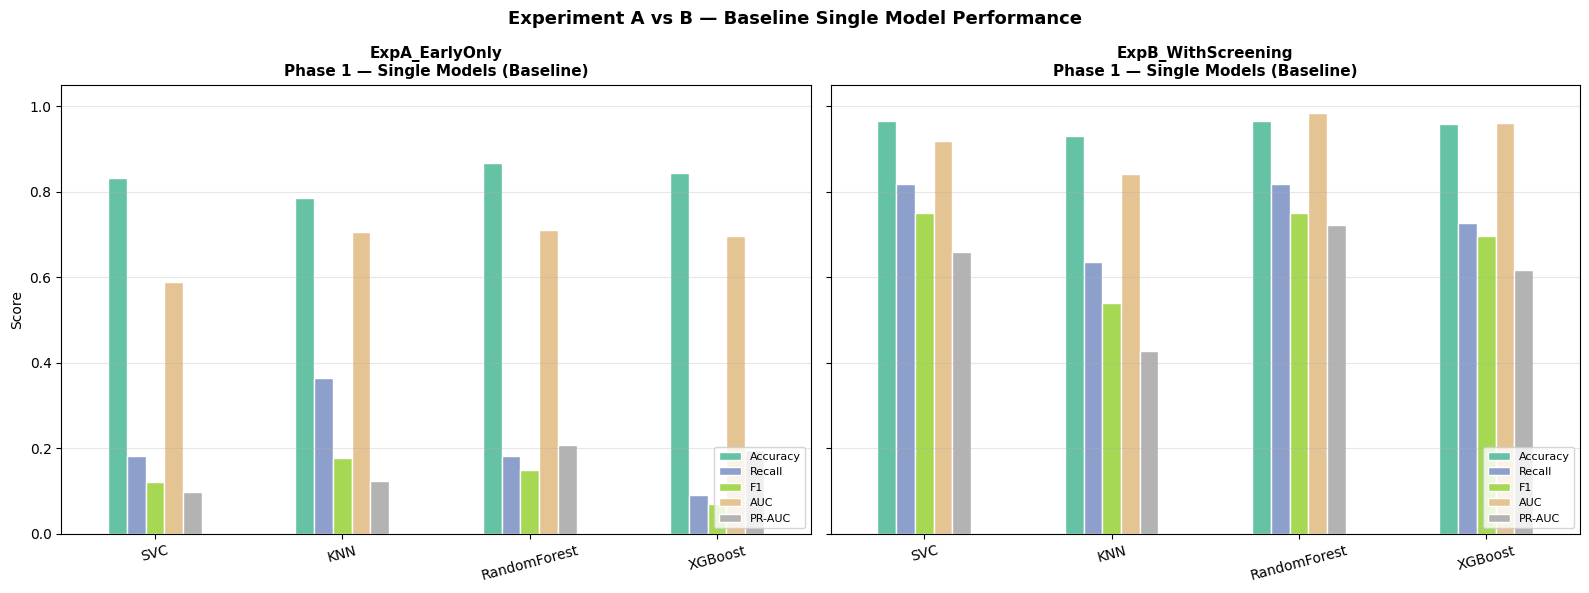

  Saved: viz1_expA_vs_expB_baseline.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, (exp_name, color) in zip(axes, zip(EXPERIMENT_CONFIGS.keys(), colors)):
    df_p1 = all_results[exp_name]["Phase1_Baseline"][metrics_show]
    df_p1.plot(kind='bar', ax=ax, ylim=(0, 1.05), colormap='Set2', rot=15, edgecolor='white')
    ax.set_title(f"{exp_name}\nPhase 1 — Single Models (Baseline)", fontsize=11, fontweight='bold')
    ax.set_ylabel("Score")
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle("Experiment A vs B — Baseline Single Model Performance",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("viz1_expA_vs_expB_baseline.png", dpi=150)
plt.show()
plt.close()
print("  Saved: viz1_expA_vs_expB_baseline.png")

### ── VIZ 1.5: Recall / Precision vs Threshold — Best Single vs Hybrid / 召回率与精度随阈值变化 — 最佳单模型 vs 混合模型 ─
### Shows how recall and precision change across the full threshold range [0, 1] for the best single model vs the best hybrid. Useful for selecting an operating threshold appropriate to the clinical context (e.g., target recall ≥ 0.90).
### 展示了最佳单一模型与最佳混合模型在整个阈值范围 [0, 1] 内的召回率和精确率变化情况。有助于选择适合临床环境的操作阈值（例如，目标召回率 ≥ 0.90）。


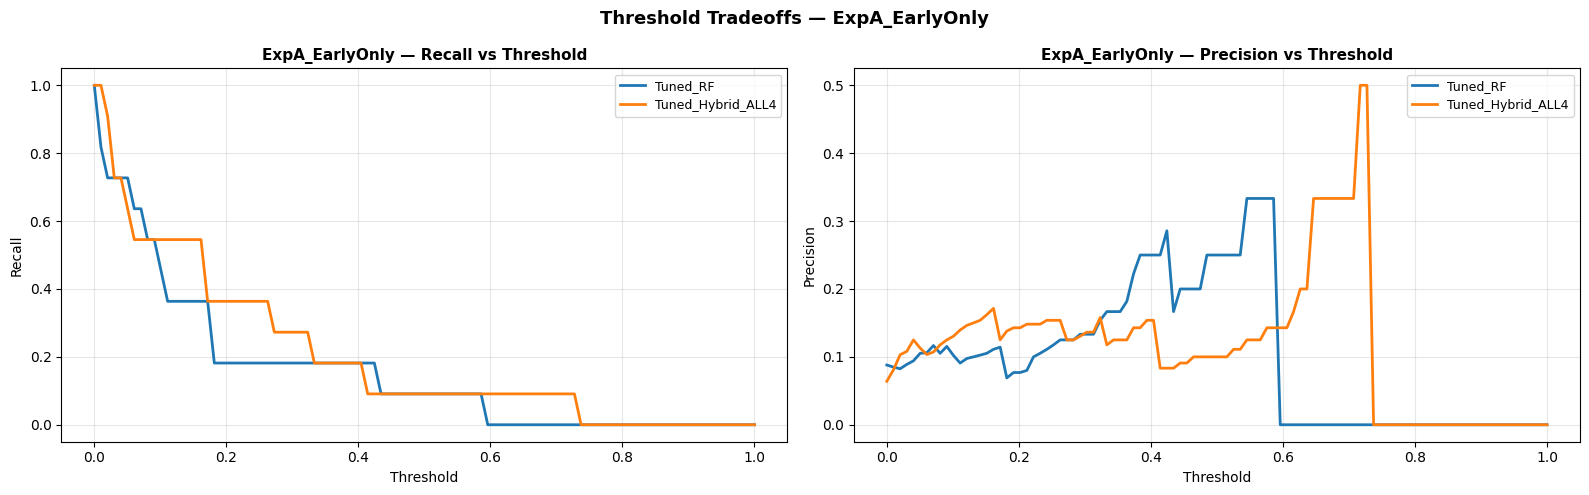

  Saved: viz1a_threshold_curves_ExpA_EarlyOnly.png


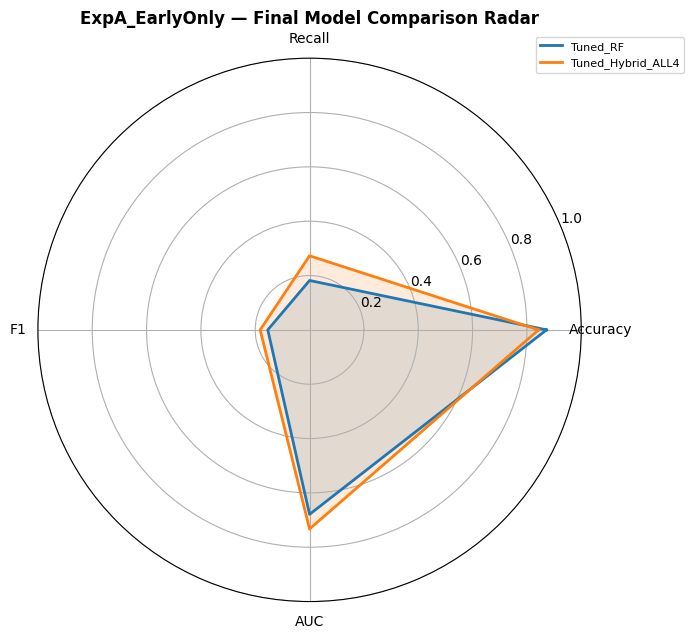

  Saved: viz1b_radar_comparison_ExpA_EarlyOnly.png


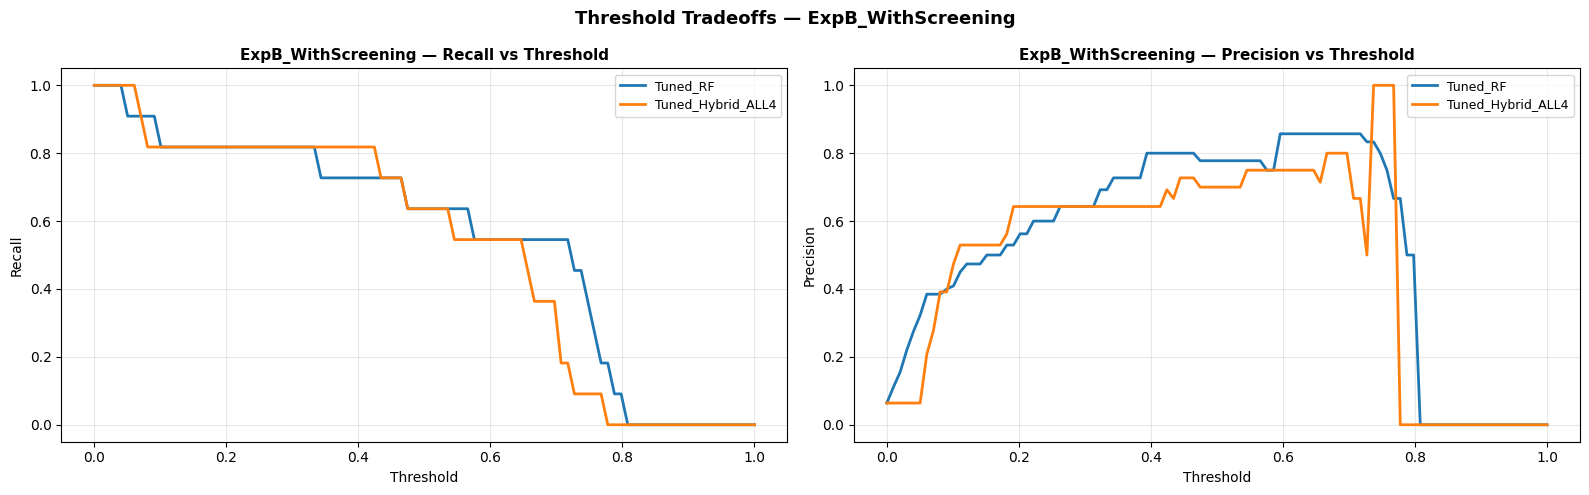

  Saved: viz1a_threshold_curves_ExpB_WithScreening.png


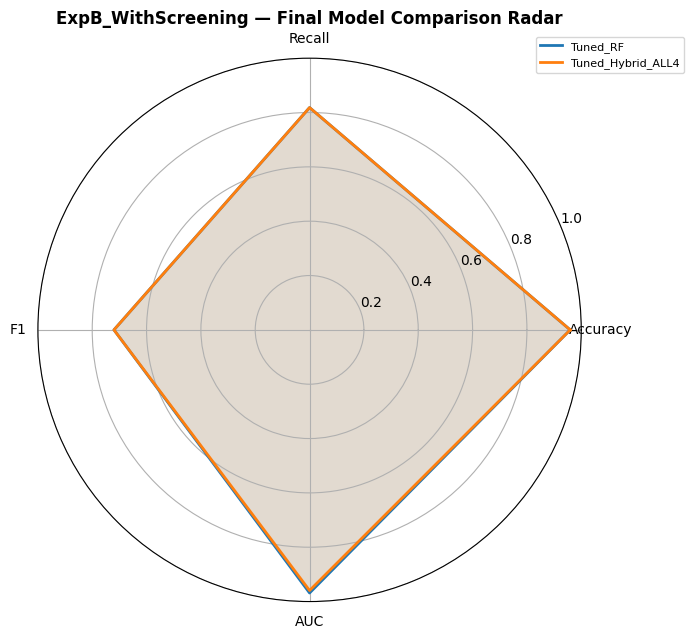

  Saved: viz1b_radar_comparison_ExpB_WithScreening.png


In [9]:
for exp_name in EXPERIMENT_CONFIGS.keys():
    p4_df = all_results[exp_name]["Phase4_Tuned"]
    single_models = [m for m in ["Tuned_SVC", "Tuned_KNN", "Tuned_RF", "Tuned_XGB"] if m in p4_df.index]
    hybrid_models = [m for m in p4_df.index if m in ["Tuned_Hybrid_ALL4", "Tuned_Stacking_ALL4"]]
    if not single_models or not hybrid_models:
        continue

    best_single = p4_df.loc[single_models, "AUC"].idxmax()
    best_hybrid = p4_df.loc[hybrid_models, "AUC"].idxmax()
    y_true = all_y_test[exp_name]
    y_prob_single = all_tuned_models[exp_name][best_single].predict_proba(all_X_test[exp_name])[:, 1]
    y_prob_hybrid = all_tuned_models[exp_name][best_hybrid].predict_proba(all_X_test[exp_name])[:, 1]

    thresholds = np.linspace(0, 1, 100)
    recall_single, precision_single = [], []
    recall_hybrid, precision_hybrid = [], []

    for t in thresholds:
        pred_single = (y_prob_single > t).astype(int)
        pred_hybrid = (y_prob_hybrid > t).astype(int)
        recall_single.append(recall_score(y_true, pred_single, zero_division=0))
        precision_single.append(precision_score(y_true, pred_single, zero_division=0))
        recall_hybrid.append(recall_score(y_true, pred_hybrid, zero_division=0))
        precision_hybrid.append(precision_score(y_true, pred_hybrid, zero_division=0))

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    axes[0].plot(thresholds, recall_single, label=best_single, linewidth=2)
    axes[0].plot(thresholds, recall_hybrid, label=best_hybrid, linewidth=2)
    axes[0].set_title(f"{exp_name} — Recall vs Threshold", fontsize=11, fontweight='bold')
    axes[0].set_xlabel("Threshold")
    axes[0].set_ylabel("Recall")
    axes[0].legend(fontsize=9)
    axes[0].grid(alpha=0.3)

    axes[1].plot(thresholds, precision_single, label=best_single, linewidth=2)
    axes[1].plot(thresholds, precision_hybrid, label=best_hybrid, linewidth=2)
    axes[1].set_title(f"{exp_name} — Precision vs Threshold", fontsize=11, fontweight='bold')
    axes[1].set_xlabel("Threshold")
    axes[1].set_ylabel("Precision")
    axes[1].legend(fontsize=9)
    axes[1].grid(alpha=0.3)

    plt.suptitle(f"Threshold Tradeoffs — {exp_name}", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"viz1a_threshold_curves_{exp_name}.png", dpi=150)
    plt.show()
    plt.close()
    print(f"  Saved: viz1a_threshold_curves_{exp_name}.png")

    # ── Radar (Spider) Chart — Best Single vs Best Hybrid ────
    # Visualises multi-metric trade-offs on a polar axis so that
    # dimension-specific weaknesses are immediately visible.
    categories = ["Accuracy", "Recall", "F1", "AUC"]
    angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
    angles += angles[:1]    # Close the polygon

    values = []
    labels = [best_single, best_hybrid]
    for model_name in labels:
        model_scores = all_results[exp_name]["Phase4_Tuned"].loc[model_name, categories].tolist()
        values.append(model_scores + [model_scores[0]])    # Close the polygon

    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, polar=True)
    for model_name, vals in zip(labels, values):
        ax.plot(angles, vals, label=model_name, linewidth=2)
        ax.fill(angles, vals, alpha=0.15)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)
    ax.set_ylim(0, 1)
    ax.set_title(f"{exp_name} — Final Model Comparison Radar", fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.05), fontsize=8)
    plt.tight_layout()
    plt.savefig(f"viz1b_radar_comparison_{exp_name}.png", dpi=150)
    plt.show()
    plt.close()
    print(f"  Saved: viz1b_radar_comparison_{exp_name}.png")

### ── VIZ 2: Phase 3 Hybrid Models — ExpA vs ExpB / 阶段3混合模型 — 实验A vs 实验B ─────────────
### Shows untuned hybrid model performance to isolate the benefit of ensemble combination before hyperparameter optimisation.
### 显示未经调整的混合模型性能，以在超参数优化之前分离集成组合的优势。

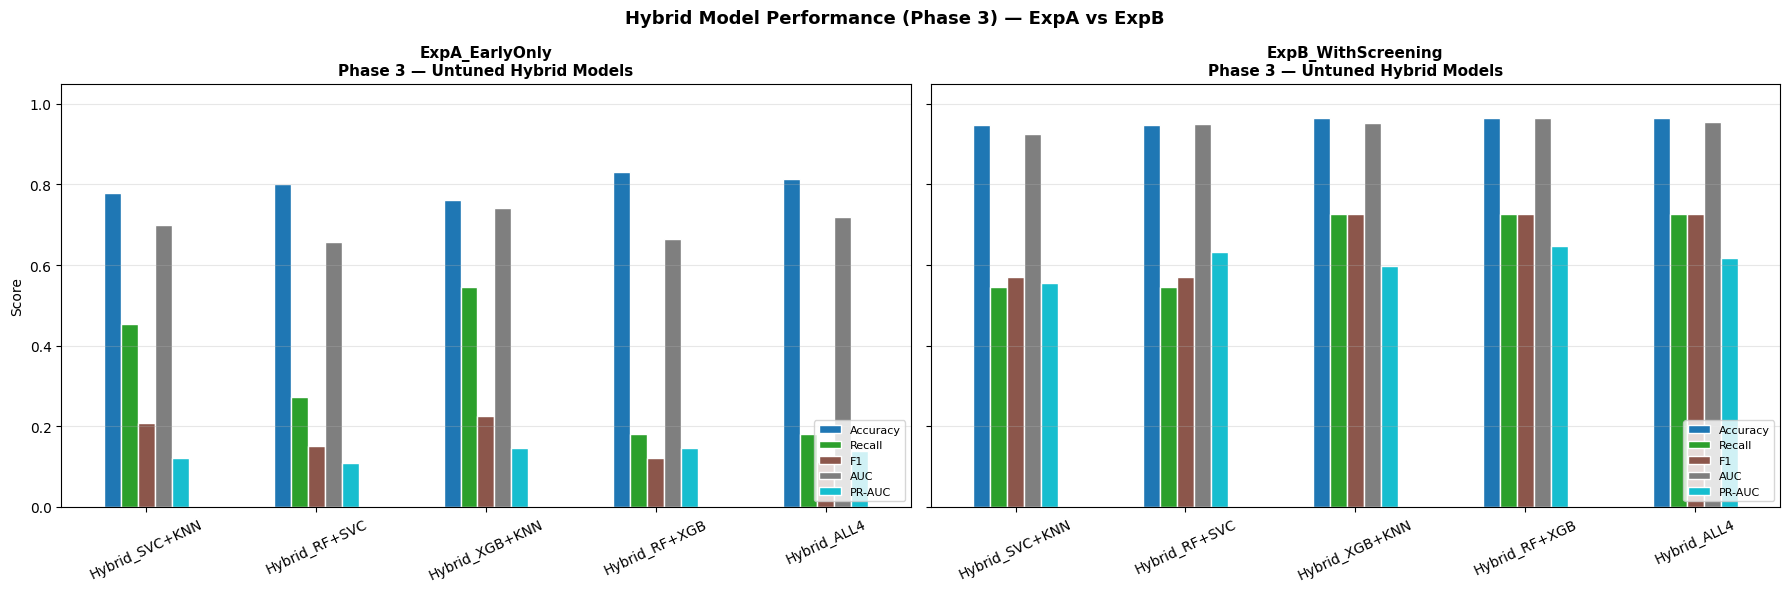

  Saved: viz2_phase3_hybrid_comparison.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
hybrid_only = ["Hybrid_SVC+KNN", "Hybrid_RF+SVC",
               "Hybrid_XGB+KNN", "Hybrid_RF+XGB", "Hybrid_ALL4"]

for ax, exp_name in zip(axes, EXPERIMENT_CONFIGS.keys()):
    df_p3 = all_results[exp_name]["Phase3_Hybrid"]
    df_p3_hybrid = df_p3[df_p3.index.isin(hybrid_only)][metrics_show]
    df_p3_hybrid.plot(kind='bar', ax=ax, ylim=(0, 1.05),
                      colormap='tab10', rot=25, edgecolor='white')
    ax.set_title(f"{exp_name}\nPhase 3 — Untuned Hybrid Models", fontsize=11, fontweight='bold')
    ax.set_ylabel("Score")
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle("Hybrid Model Performance (Phase 3) — ExpA vs ExpB",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("viz2_phase3_hybrid_comparison.png", dpi=150)
plt.show()
plt.close()
print("  Saved: viz2_phase3_hybrid_comparison.png")

### ── VIZ 3: Phase 4 Tuned Hybrids — ExpA vs ExpB / 阶段4调参混合模型 — 实验A vs 实验B ─────────────
### Same layout as Viz 2 but for the tuned ensembles, showing the incremental gain from hyperparameter optimisation.
### 与 Viz 2 相同的布局，但针对的是经过调整的集成，显示超参数优化带来的增量增益。

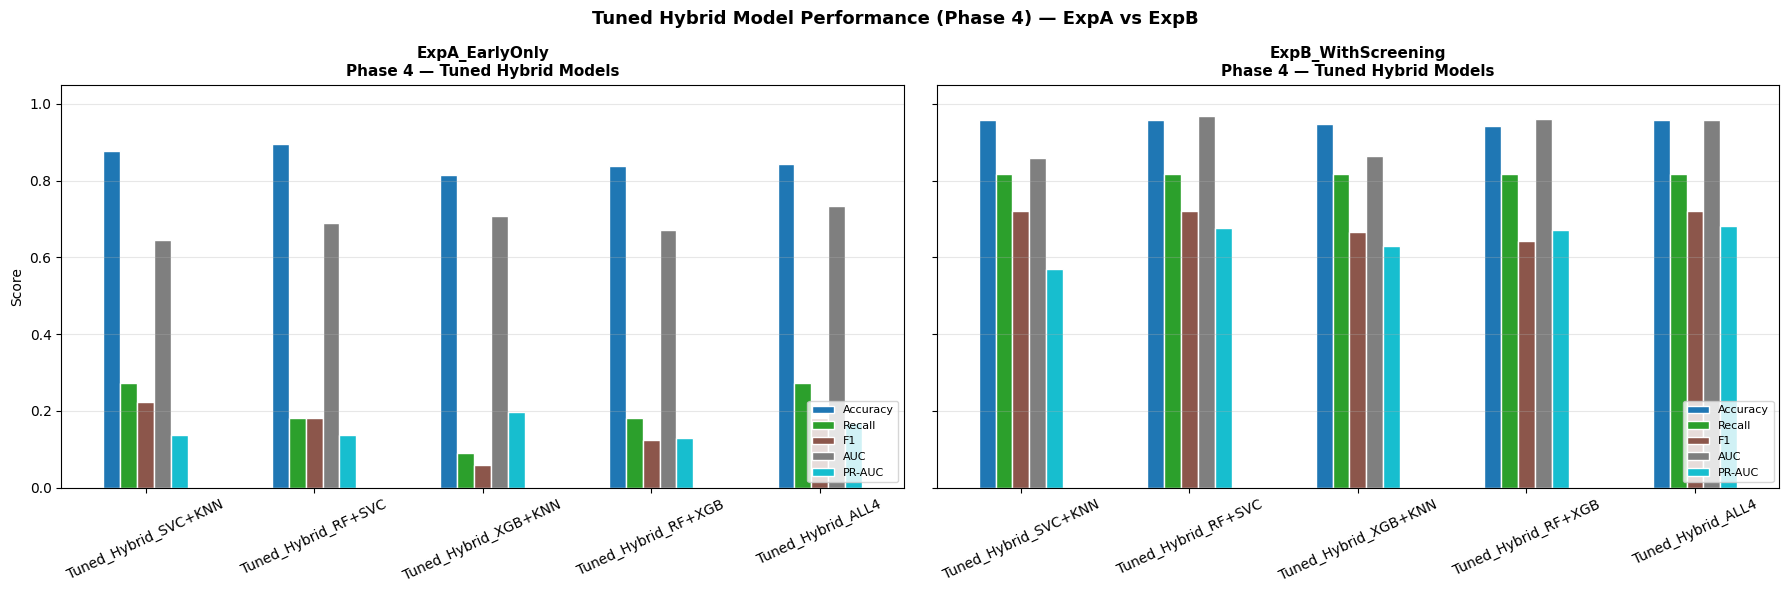

  Saved: viz3_phase4_tuned_hybrid_comparison.png


In [11]:
tuned_hybrid_only = ["Tuned_Hybrid_SVC+KNN", "Tuned_Hybrid_RF+SVC",
                     "Tuned_Hybrid_XGB+KNN", "Tuned_Hybrid_RF+XGB", "Tuned_Hybrid_ALL4"]

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
for ax, exp_name in zip(axes, EXPERIMENT_CONFIGS.keys()):
    df_p4 = all_results[exp_name]["Phase4_Tuned"]
    df_p4_hybrid = df_p4[df_p4.index.isin(tuned_hybrid_only)][metrics_show]
    df_p4_hybrid.plot(kind='bar', ax=ax, ylim=(0, 1.05),
                      colormap='tab10', rot=25, edgecolor='white')
    ax.set_title(f"{exp_name}\nPhase 4 — Tuned Hybrid Models", fontsize=11, fontweight='bold')
    ax.set_ylabel("Score")
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle("Tuned Hybrid Model Performance (Phase 4) — ExpA vs ExpB",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("viz3_phase4_tuned_hybrid_comparison.png", dpi=150)
plt.show()
plt.close()
print("  Saved: viz3_phase4_tuned_hybrid_comparison.png")

### ── VIZ 4: ROC Curves — Phase 4 Tuned Hybrids (side by side) / ROC曲线 — 阶段4调参混合模型并列展示 ─
### Receiver Operating Characteristic curves plotted for all Phase 4 models (individual + hybrid).  Hybrid models are drawn with thicker solid lines; individuals use dashed lines, making it easy to see the ensemble improvement.
### 绘制了所有第四阶段模型（个体模型+混合模型）的接收者操作特征曲线。混合模型用较粗的实线绘制；个体模型用虚线绘制，以便于观察整体改进情况。

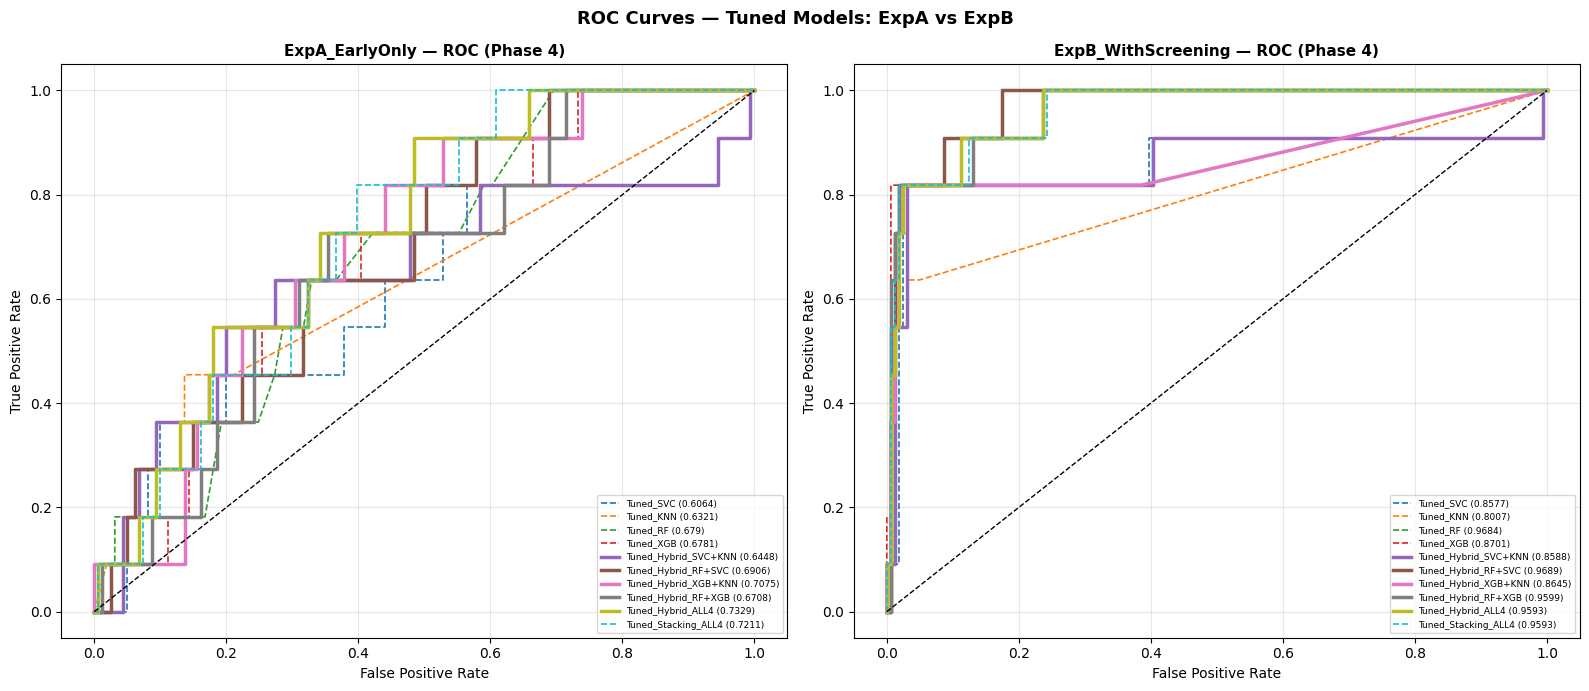

  Saved: viz4_roc_tuned_expA_vs_expB.png


In [12]:
# ── VIZ 4: ROC Curves — Phase 4 Tuned Hybrids (side by side) ─
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, exp_name in zip(axes, EXPERIMENT_CONFIGS.keys()):
    roc_data = all_roc_data[exp_name]["Phase4_Tuned"]
    for name, (fpr, tpr, auc) in roc_data.items():
        lw = 2.5 if "Hybrid" in name else 1.2
        ls = '-'  if "Hybrid" in name else '--'
        ax.plot(fpr, tpr, label=f"{name} ({auc})", linewidth=lw, linestyle=ls)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1)    # Random-classifier diagonal
    ax.set_title(f"{exp_name} — ROC (Phase 4)", fontsize=11, fontweight='bold')
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=6.5, loc='lower right')
    ax.grid(alpha=0.3)

plt.suptitle("ROC Curves — Tuned Models: ExpA vs ExpB",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("viz4_roc_tuned_expA_vs_expB.png", dpi=150)
plt.show()
plt.close()
print("  Saved: viz4_roc_tuned_expA_vs_expB.png")

### ── VIZ 5: AUC Progression — P1 → P3 → P4 per experiment / AUC演进 — P1 → P3 → P4（每个实验） ────
### Line chart showing how each model's AUC evolves across phases.
### Individual models trace P1 → P3 → P4 with dashed lines;
### hybrid models start at P3 (where they first appear) with bold solid lines.  Any upward slope from P3 to P4 indicates a tuning benefit.
### 折线图展示了各模型 AUC 随阶段的变化情况。
### 单个模型以虚线表示 P1 → P3 → P4 的变化；
### 混合模型以粗实线表示，其变化从 P3（首次出现的位置）开始。从 P3 到 P4 的任何上升斜率都表明模型调优效果良好。

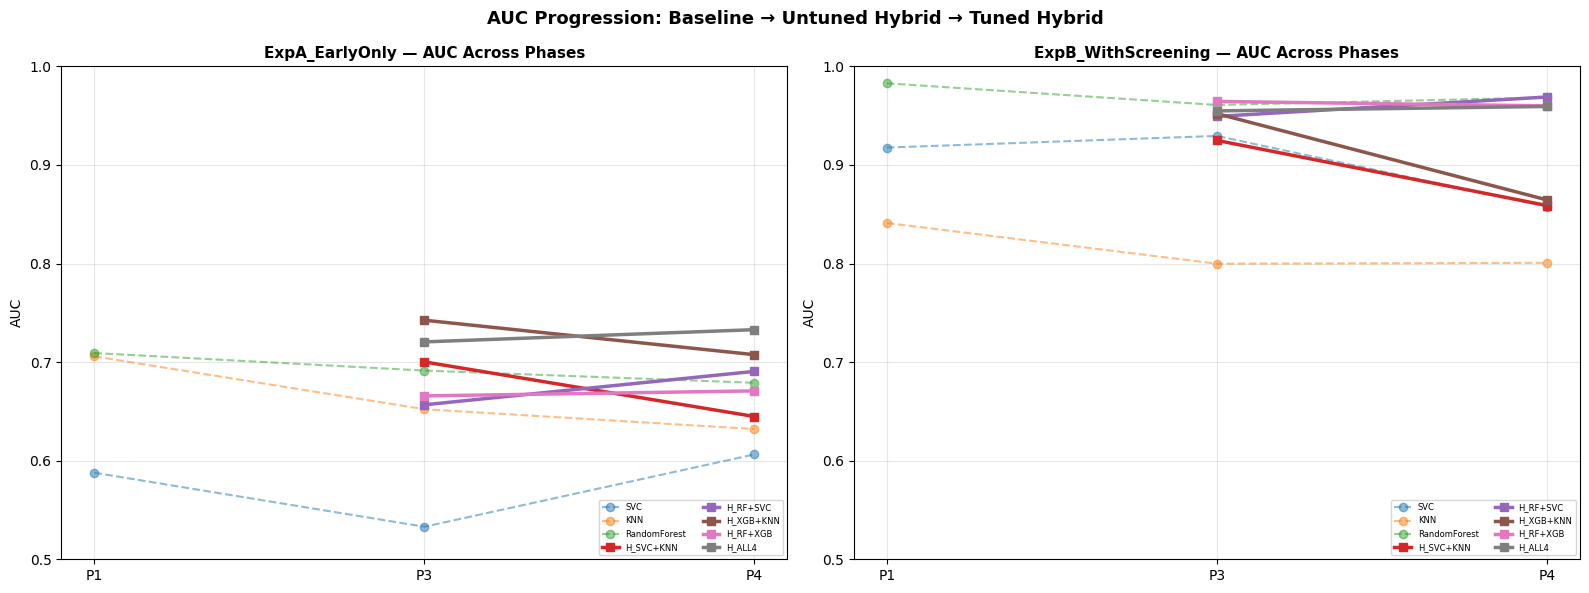

  Saved: viz5_auc_progression.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
phase_map = {
    "Phase1_Baseline": "P1 Baseline",
    "Phase3_Hybrid":   "P3 Hybrid",
    "Phase4_Tuned":    "P4 Tuned",
}
# Track hybrids across phases (matching by suffix)
hybrid_labels_p3 = ["Hybrid_SVC+KNN", "Hybrid_RF+SVC",
                     "Hybrid_XGB+KNN", "Hybrid_RF+XGB", "Hybrid_ALL4"]
hybrid_labels_p4 = ["Tuned_" + h for h in hybrid_labels_p3]

for ax, exp_name in zip(axes, EXPERIMENT_CONFIGS.keys()):
    p1_auc = all_results[exp_name]["Phase1_Baseline"]["AUC"]
    p3_df  = all_results[exp_name]["Phase3_Hybrid"]
    p4_df  = all_results[exp_name]["Phase4_Tuned"]

    # Plot individual model trajectories P1 → P4
    for base_model in ["SVC", "KNN", "RandomForest", "XGBoost"]:
        tuned_key = "Tuned_" + ("RF" if base_model == "RandomForest" else base_model)
        if base_model in p3_df.index and tuned_key in p4_df.index:
            y_vals = [
                p1_auc.get(base_model, np.nan),
                p3_df.loc[base_model, "AUC"] if base_model in p3_df.index else np.nan,
                p4_df.loc[tuned_key, "AUC"],
            ]
            ax.plot(["P1", "P3", "P4"], y_vals, marker='o', linestyle='--',
                    alpha=0.5, label=base_model)

    # Plot hybrid trajectories P3 → P4 (bold)
    for h3, h4 in zip(hybrid_labels_p3, hybrid_labels_p4):
        if h3 in p3_df.index and h4 in p4_df.index:
            y_vals = [np.nan, p3_df.loc[h3, "AUC"], p4_df.loc[h4, "AUC"]]
            ax.plot(["P1", "P3", "P4"], y_vals, marker='s', linewidth=2.5,
                    label=h3.replace("Hybrid_", "H_"))

    ax.set_ylim(0.5, 1.0)
    ax.set_title(f"{exp_name} — AUC Across Phases", fontsize=11, fontweight='bold')
    ax.set_ylabel("AUC")
    ax.legend(fontsize=6, loc='lower right', ncol=2)
    ax.grid(alpha=0.3)

plt.suptitle("AUC Progression: Baseline → Untuned Hybrid → Tuned Hybrid",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("viz5_auc_progression.png", dpi=150)
plt.show()
plt.close()
print("  Saved: viz5_auc_progression.png")

### ── VIZ 6: Confusion Matrices — Best Model per Experiment / 混淆矩阵 — 每个实验最佳模型 ────
### Confusion matrix at threshold=0.3 (rather than 0.5) to reflect the clinical priority of minimising false negatives.
### The four cells represent:
- ###  TN (top-left)  — correctly predicted negative
- ###  FP (top-right) — false alarm (unnecessary biopsy)
- ###  FN (bot-left)  — missed cancer (critical error)
- ### TP (bot-right) — correctly predicted positive
### 混淆矩阵阈值设为 0.3（而非 0.5），以体现临床上优先考虑减少假阴性结果的原则。

### 四个单元格分别代表：
- ### TN（左上）— 正确预测为阴性
- ### FP（右上）— 假阳性（不必要的活检）
- ### FN（左下）— 漏诊癌症（严重错误）
- ### TP（右下）— 正确预测为阳性

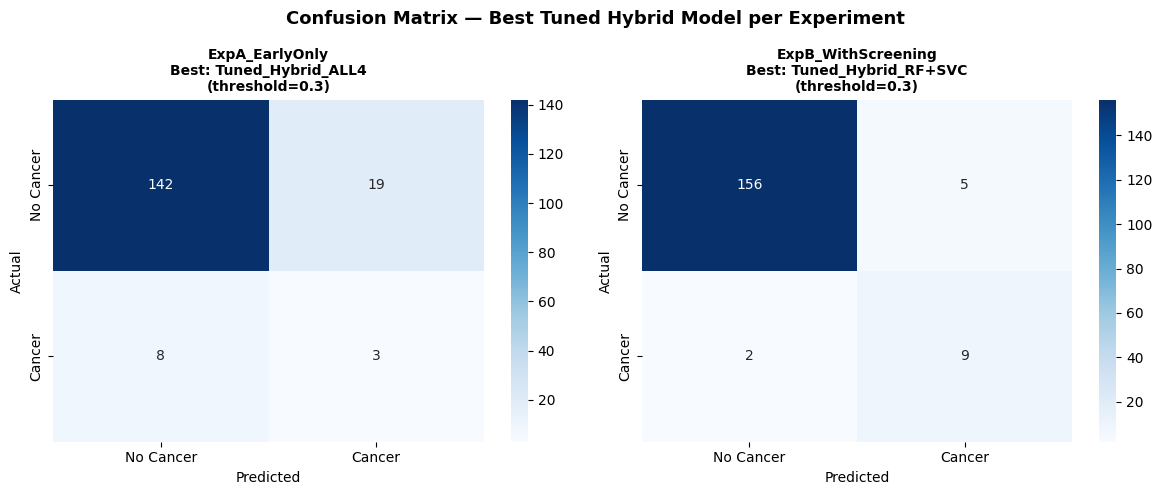

  Saved: viz6_confusion_matrices.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, exp_name in zip(axes, EXPERIMENT_CONFIGS.keys()):
    best_name, best_model = all_best_models[exp_name]
    X_te  = all_X_test[exp_name]
    y_te  = all_y_test[exp_name]

    y_prob_best = best_model.predict_proba(X_te)[:, 1]
    # Use 0.3 threshold to boost recall (more important in medical screening)
    y_pred_best = (y_prob_best > 0.3).astype(int)
    cm = confusion_matrix(y_te, y_pred_best)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Cancer', 'Cancer'],
                yticklabels=['No Cancer', 'Cancer'])
    ax.set_title(f"{exp_name}\nBest: {best_name}\n(threshold=0.3)",
                 fontsize=10, fontweight='bold')
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrix — Best Tuned Hybrid Model per Experiment",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("viz6_confusion_matrices.png", dpi=150)
plt.show()
plt.close()
print("  Saved: viz6_confusion_matrices.png")

### ── VIZ 7: Cross-Experiment Summary Heatmap / 跨实验汇总热图 ─────────────────
### Two heatmaps (AUC and Recall) showing every tuned hybrid model (rows) × experiment (columns).  Darker cells = higher values.
### Enables rapid identification of which hybrid configuration transfers well between the two experimental settings.
### 两张热图（AUC 和召回率）分别展示了每个调优后的混合模型（行）与实验（列）的对应关系。颜色越深表示数值越高。
### 能够快速识别哪种混合配置在两种实验设置之间具有良好的迁移性。

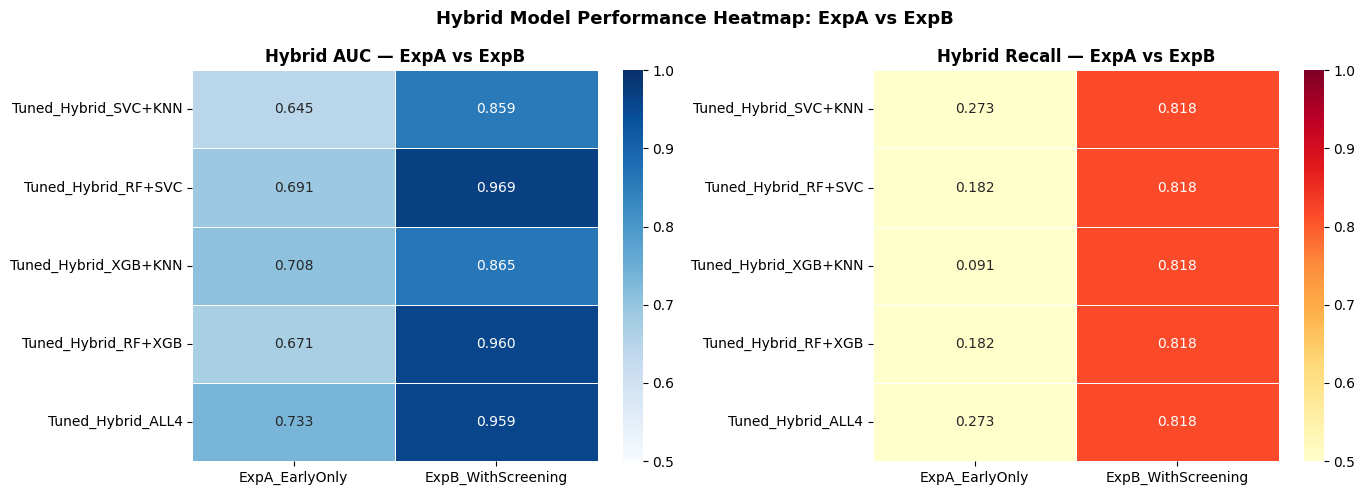

  Saved: viz7_hybrid_heatmap_expA_vs_expB.png


In [15]:
# AUC of all hybrid models across both experiments
rows = {}
for exp_name in EXPERIMENT_CONFIGS.keys():
    p4_df = all_results[exp_name]["Phase4_Tuned"]
    for model_name in tuned_hybrid_only:
        if model_name in p4_df.index:
            rows.setdefault(model_name, {})[exp_name] = p4_df.loc[model_name, "AUC"]

heatmap_df = pd.DataFrame(rows).T

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for metric, ax in zip(["AUC", "Recall"], axes):
    metric_rows = {}
    for exp_name in EXPERIMENT_CONFIGS.keys():
        p4_df = all_results[exp_name]["Phase4_Tuned"]
        for model_name in tuned_hybrid_only:
            if model_name in p4_df.index:
                metric_rows.setdefault(model_name, {})[exp_name] = p4_df.loc[model_name, metric]
    metric_df = pd.DataFrame(metric_rows).T
    sns.heatmap(metric_df, annot=True, fmt=".3f",
                cmap="Blues" if metric == "AUC" else "YlOrRd",
                ax=ax, vmin=0.5, vmax=1.0, linewidths=0.5)
    ax.set_title(f"Hybrid {metric} — ExpA vs ExpB", fontweight='bold')

plt.suptitle("Hybrid Model Performance Heatmap: ExpA vs ExpB",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("viz7_hybrid_heatmap_expA_vs_expB.png", dpi=150)
plt.show()
plt.close()
print("  Saved: viz7_hybrid_heatmap_expA_vs_expB.png")

### ── VIZ 8: Phase 4 Full — Both Experiments All Models / 阶段4完整结果 — 两个实验所有模型 ────────
### All Phase 4 models (individual + hybrid) for both experiments in a single tall figure.  Hybrid model bars are outlined in red to make them immediately distinguishable from individuals.
### 图中展示了两个实验中所有第四阶段模型（个体模型+混合模型）的竖图。混合模型柱状图以红色边框标出，以便与个体模型快速区分。

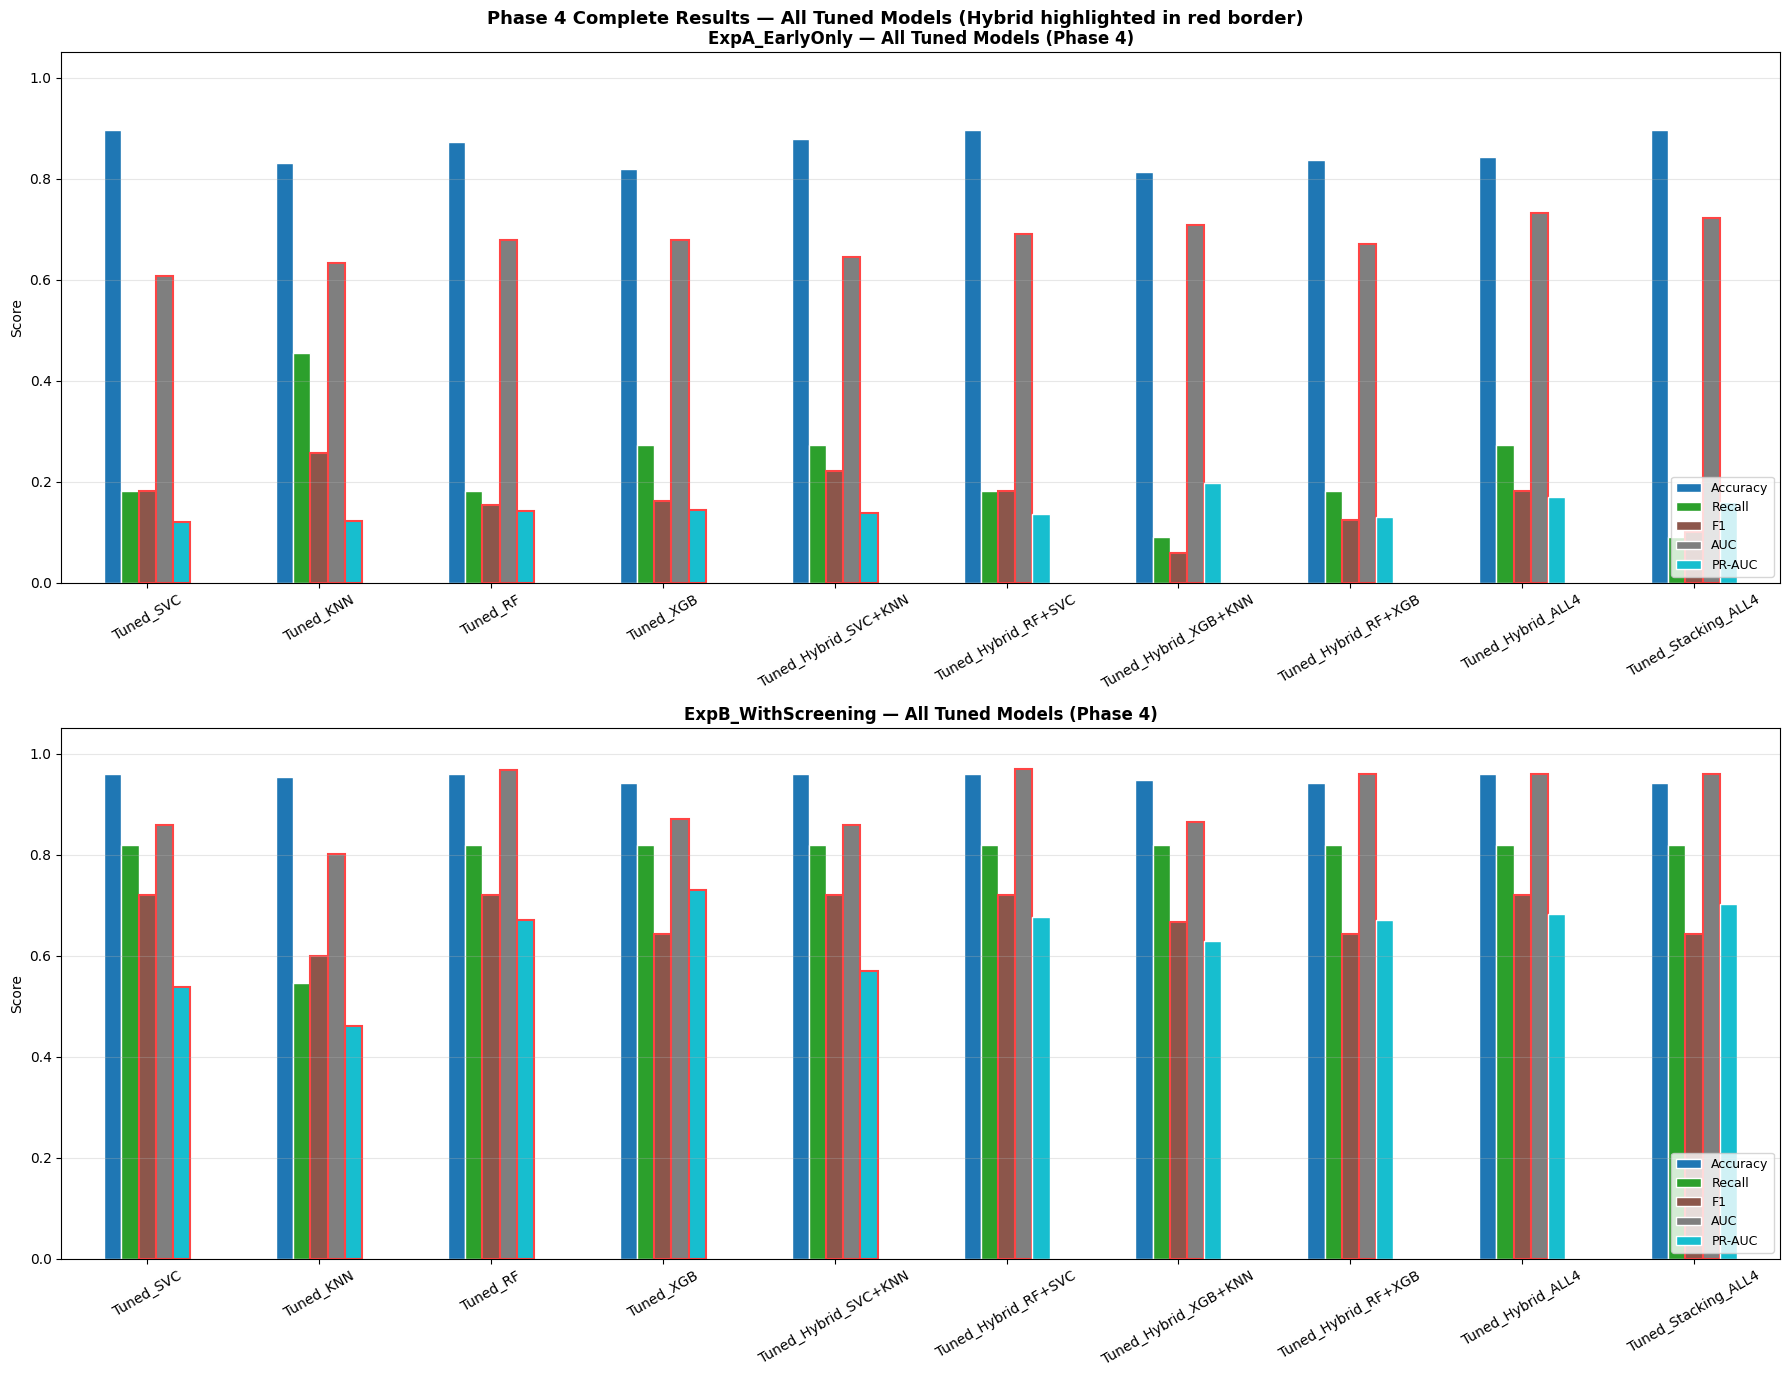

  Saved: viz8_phase4_full_both_experiments.png
  Tuned_RF: recall = 0.7455 ± 0.0680
  Tuned_XGB: recall = 0.8727 ± 0.0727
  Tuned_Hybrid_RF+XGB: recall = 0.8727 ± 0.0727
  Tuned_Hybrid_ALL4: recall = 0.6000 ± 0.1233
  Tuned_Stacking_ALL4: recall = 0.9091 ± 0.0813


In [16]:
fig, axes = plt.subplots(2, 1, figsize=(18, 14))
for ax, exp_name in zip(axes, EXPERIMENT_CONFIGS.keys()):
    df_p4 = all_results[exp_name]["Phase4_Tuned"][metrics_show]
    df_p4.plot(kind='bar', ax=ax, ylim=(0, 1.05),
               colormap='tab10', rot=30, edgecolor='white')
    ax.set_title(f"{exp_name} — All Tuned Models (Phase 4)", fontsize=12, fontweight='bold')
    ax.set_ylabel("Score")
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    # Highlight hybrid bars
    for patch_idx, model_name in enumerate(df_p4.index):
        if "Hybrid" in model_name:
            n_metrics = len(metrics_show)
            for i in range(n_metrics):
                ax.patches[patch_idx * n_metrics + i].set_edgecolor('#FF4444')
                ax.patches[patch_idx * n_metrics + i].set_linewidth(1.5)

plt.suptitle("Phase 4 Complete Results — All Tuned Models (Hybrid highlighted in red border)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("viz8_phase4_full_both_experiments.png", dpi=150)
plt.show()
plt.close()
print("  Saved: viz8_phase4_full_both_experiments.png")

# ── Cross-Validation Stability Analysis ───────────────────────
# Compares five key models across 5-fold stratified CV to assess
# whether held-out performance is consistent or a lucky artefact.
# Uses the last experiment's tuned_models and X_sel / y_full
# (ExpB at this point in the loop; adapt if ExpA is desired).
compare_models = {
    'Tuned_RF':            tuned_models['Tuned_RF'],
    'Tuned_XGB':           tuned_models['Tuned_XGB'],
    'Tuned_Hybrid_RF+XGB': tuned_models['Tuned_Hybrid_RF+XGB'],
    'Tuned_Hybrid_ALL4':   tuned_models['Tuned_Hybrid_ALL4'],
    'Tuned_Stacking_ALL4': tuned_models['Tuned_Stacking_ALL4'],
}
# NOTE: X_sel and selected here refer to the last experiment
# in the loop (ExpB).  To compare ExpA models, re-index X_sel
# using all_selected["ExpA_EarlyOnly"].
stability_results = cv_stability_compare(
    compare_models, X_sel[selected], y_full
)

# ─────────────────────────────────────────────────────────────
# SECTION 8: SHAP INTERPRETABILITY (ExpB Best Model Only)  / SHAP 可解释性（ExpB 最佳模型）
# ─────────────────────────────────────────────────────────────

### SHAP (SHapley Additive exPlanations) attributes each prediction to individual input features using game-theoretic Shapley values.
### <br>
### WHY ExpB?
###   ExpB's best model typically achieves near-perfect AUC, making   its feature attributions clinically meaningful (we can trust   the model's reasoning).  ExpA's weaker performance makes   feature attribution less reliable.
### <br>
### WHY UNWRAP THE VOTINGCLASSIFIER?
###   shap.TreeExplainer is optimised for tree-based models.   
### VotingClassifier is not directly supported, so we extract the  first tree-based sub-estimator (RF or XGBoost) to run SHAP.
### ─────────────────────────────────────────────────────────────
### SHAP（Shapley Additive exPlanations，夏普利加性解释）使用博弈论中的夏普利值将每个预测结果归因于各个输入特征。
### <br>
### 为什么选择 ExpB？
### ExpB 的最佳模型通常能达到接近完美的 AUC 值，使其特征归因具有临床意义（我们可以信任模型的推理）。ExpA 的性能较弱，因此特征归因的可靠性较低。
### <br>
### 为什么要解包投票分类器？
### shap.TreeExplainer 针对基于树的模型进行了优化。
### 投票分类器不被直接支持，因此我们提取第一个基于树的子估计器（随机森林或 XGBoost）来运行 SHAP。

In [17]:
if SHAP_AVAILABLE:
    print_section("SHAP INTERPRETABILITY — ExpB Best Model")

    exp_name_shap = "ExpB_WithScreening"
    best_name_shap, best_model_shap = all_best_models[exp_name_shap]
    selected_shap  = all_selected[exp_name_shap]
    X_te_shap      = all_X_test[exp_name_shap]
    y_te_shap      = all_y_test[exp_name_shap]

    # Unwrap VotingClassifier to get tree-based estimator for SHAP
    shap_target_model = best_model_shap
    if isinstance(best_model_shap, VotingClassifier):
        for label, est in best_model_shap.named_estimators_.items():
            if isinstance(est, (RandomForestClassifier, XGBClassifier)):
                shap_target_model = est
                print(f"  Unwrapped VotingClassifier → using '{label}' for SHAP")
                break

    print(f"  Running SHAP for: {best_name_shap}")
    explainer   = shap.TreeExplainer(shap_target_model)
    X_te_df     = pd.DataFrame(X_te_shap, columns=selected_shap)
    shap_values = explainer.shap_values(X_te_df)

    # shap_values is a list [neg_class, pos_class] for classifiers;
    # take index [1] for the positive-class (cancer) attributions.
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values

    # ── Summary Beeswarm Plot ─────────────────────────────────
    # Each dot = one test sample; x-axis = SHAP value (impact on
    # log-odds); colour = feature value (red = high, blue = low).
    plt.figure()
    shap.summary_plot(sv, X_te_df, show=False, max_display=18)
    plt.title(f"SHAP Summary — {best_name_shap} ({exp_name_shap})", fontweight='bold')
    plt.tight_layout()
    plt.savefig("shap_summary_expB.png", dpi=150, bbox_inches='tight')
    plt.close()
    print("  Saved: shap_summary_expB.png")

    # ── Bar Feature Importance Plot ───────────────────────────
    # Shows mean |SHAP value| for each feature — a global summary
    # of which features drive the model's predictions most.
    plt.figure()
    shap.summary_plot(sv, X_te_df, plot_type='bar', show=False, max_display=18)
    plt.title(f"SHAP Feature Importance — {best_name_shap}", fontweight='bold')
    plt.tight_layout()
    plt.savefig("shap_importance_expB.png", dpi=150, bbox_inches='tight')
    plt.close()
    print("  Saved: shap_importance_expB.png")
else:
    print("\nSHAP ANALYSIS SKIPPED (pip install shap to enable)")


  SHAP INTERPRETABILITY — ExpB Best Model
  Unwrapped VotingClassifier → using 'rf' for SHAP
  Running SHAP for: Tuned_Hybrid_RF+SVC
  Saved: shap_summary_expB.png
  Saved: shap_importance_expB.png


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

# ─────────────────────────────────────────────────────────────
# SECTION 9: FINAL SUMMARY TABLES
# ─────────────────────────────────────────────────────────────

In [18]:
print_section("FINAL SUMMARY — ALL PHASES & EXPERIMENTS")

all_summaries = {}

for exp_name in EXPERIMENT_CONFIGS.keys():
    rows = {}
    # Phase 1: all individual baseline models
    for m, row in all_results[exp_name]["Phase1_Baseline"].iterrows():
        rows[f"[P1] {m}"] = row[metrics_show]
    # Phase 3: hybrid ensembles only (individuals already in P1)
    for m, row in all_results[exp_name]["Phase3_Hybrid"].iterrows():
        if "Hybrid" in m:
            rows[f"[P3] {m}"] = row[metrics_show]
    # Phase 4: all tuned models (individuals + hybrids)
    for m, row in all_results[exp_name]["Phase4_Tuned"].iterrows():
        rows[f"[P4] {m}"] = row[metrics_show]

    summary_df = pd.DataFrame(rows).T
    all_summaries[exp_name] = summary_df

    print(f"\n  ===== {exp_name} =====")
    print(summary_df.to_string())

    csv_name = f"final_summary_{exp_name}.csv"
    csv_path = safe_save_csv(summary_df, csv_name)
    print(f"  Saved: {csv_path}")

# ── Cross-Experiment Best-Hybrid Comparison ───────────────────
# Identifies the top-performing tuned hybrid from each experiment
# (by AUC) and presents them side by side for direct comparison.
print("\n  ===== BEST HYBRID MODEL COMPARISON =====")
comparison_rows = {}
for exp_name in EXPERIMENT_CONFIGS.keys():
    p4 = all_results[exp_name]["Phase4_Tuned"]
    hybrids = p4[p4.index.isin(tuned_hybrid_only)]
    best_idx = hybrids["AUC"].idxmax()
    comparison_rows[exp_name] = hybrids.loc[best_idx, metrics_show]
    comparison_rows[exp_name]["Best_Model"] = best_idx

comp_df = pd.DataFrame(comparison_rows).T
print(comp_df.to_string())
comp_path = safe_save_csv(comp_df, "comparison_best_hybrid_expA_vs_expB.csv")
print(f"\n  Saved: {comp_path}")


  FINAL SUMMARY — ALL PHASES & EXPERIMENTS

  ===== ExpA_EarlyOnly =====
                           Accuracy  Recall      F1     AUC  PR-AUC
[P1] SVC                     0.8314  0.1818  0.1212  0.5878  0.0970
[P1] KNN                     0.7849  0.3636  0.1778  0.7058  0.1241
[P1] RandomForest            0.8663  0.1818  0.1481  0.7092  0.2072
[P1] XGBoost                 0.8430  0.0909  0.0690  0.6957  0.1970
[P3] Hybrid_SVC+KNN          0.7791  0.4545  0.2083  0.7002  0.1221
[P3] Hybrid_RF+SVC           0.8023  0.2727  0.1500  0.6567  0.1083
[P3] Hybrid_XGB+KNN          0.7616  0.5455  0.2264  0.7425  0.1461
[P3] Hybrid_RF+XGB           0.8314  0.1818  0.1212  0.6657  0.1460
[P3] Hybrid_ALL4             0.8140  0.1818  0.1111  0.7205  0.1381
[P4] Tuned_SVC               0.8953  0.1818  0.1818  0.6064  0.1196
[P4] Tuned_KNN               0.8314  0.4545  0.2564  0.6321  0.1225
[P4] Tuned_RF                0.8721  0.1818  0.1538  0.6790  0.1411
[P4] Tuned_XGB               0.8198  0.272

# ─────────────────────────────────────────────────────────────
# SECTION 10: PIPELINE COMPLETION
# ─────────────────────────────────────────────────────────────


  PIPELINE COMPLETE

  Output files:
  ┌─ Data / CSV
  │   final_summary_ExpA_EarlyOnly.csv
  │   final_summary_ExpB_WithScreening.csv
  │   comparison_best_hybrid_expA_vs_expB.csv
  │
  ├─ Feature Importance
  │   feature_importance_ExpA_EarlyOnly.png
  │   feature_importance_ExpB_WithScreening.png
  │
  ├─ Visualizations
  │   viz1_expA_vs_expB_baseline.png          ← Phase 1 baseline comparison
  │   viz1a_threshold_curves_<exp>.png        ← Recall/Precision vs threshold
  │   viz1b_radar_comparison_<exp>.png        ← Multi-metric radar chart
  │   viz2_phase3_hybrid_comparison.png       ← Untuned hybrid performance
  │   viz3_phase4_tuned_hybrid_comparison.png ← Tuned hybrid performance
  │   viz4_roc_tuned_expA_vs_expB.png         ← ROC curves (Phase 4)
  │   viz5_auc_progression.png               ← AUC trend P1→P3→P4
  │   viz6_confusion_matrices.png            ← Confusion matrix (threshold=0.3)
  │   viz7_hybrid_heatmap_expA_vs_expB.png   ← AUC/Recall heatmap
  │   viz8_phase4_

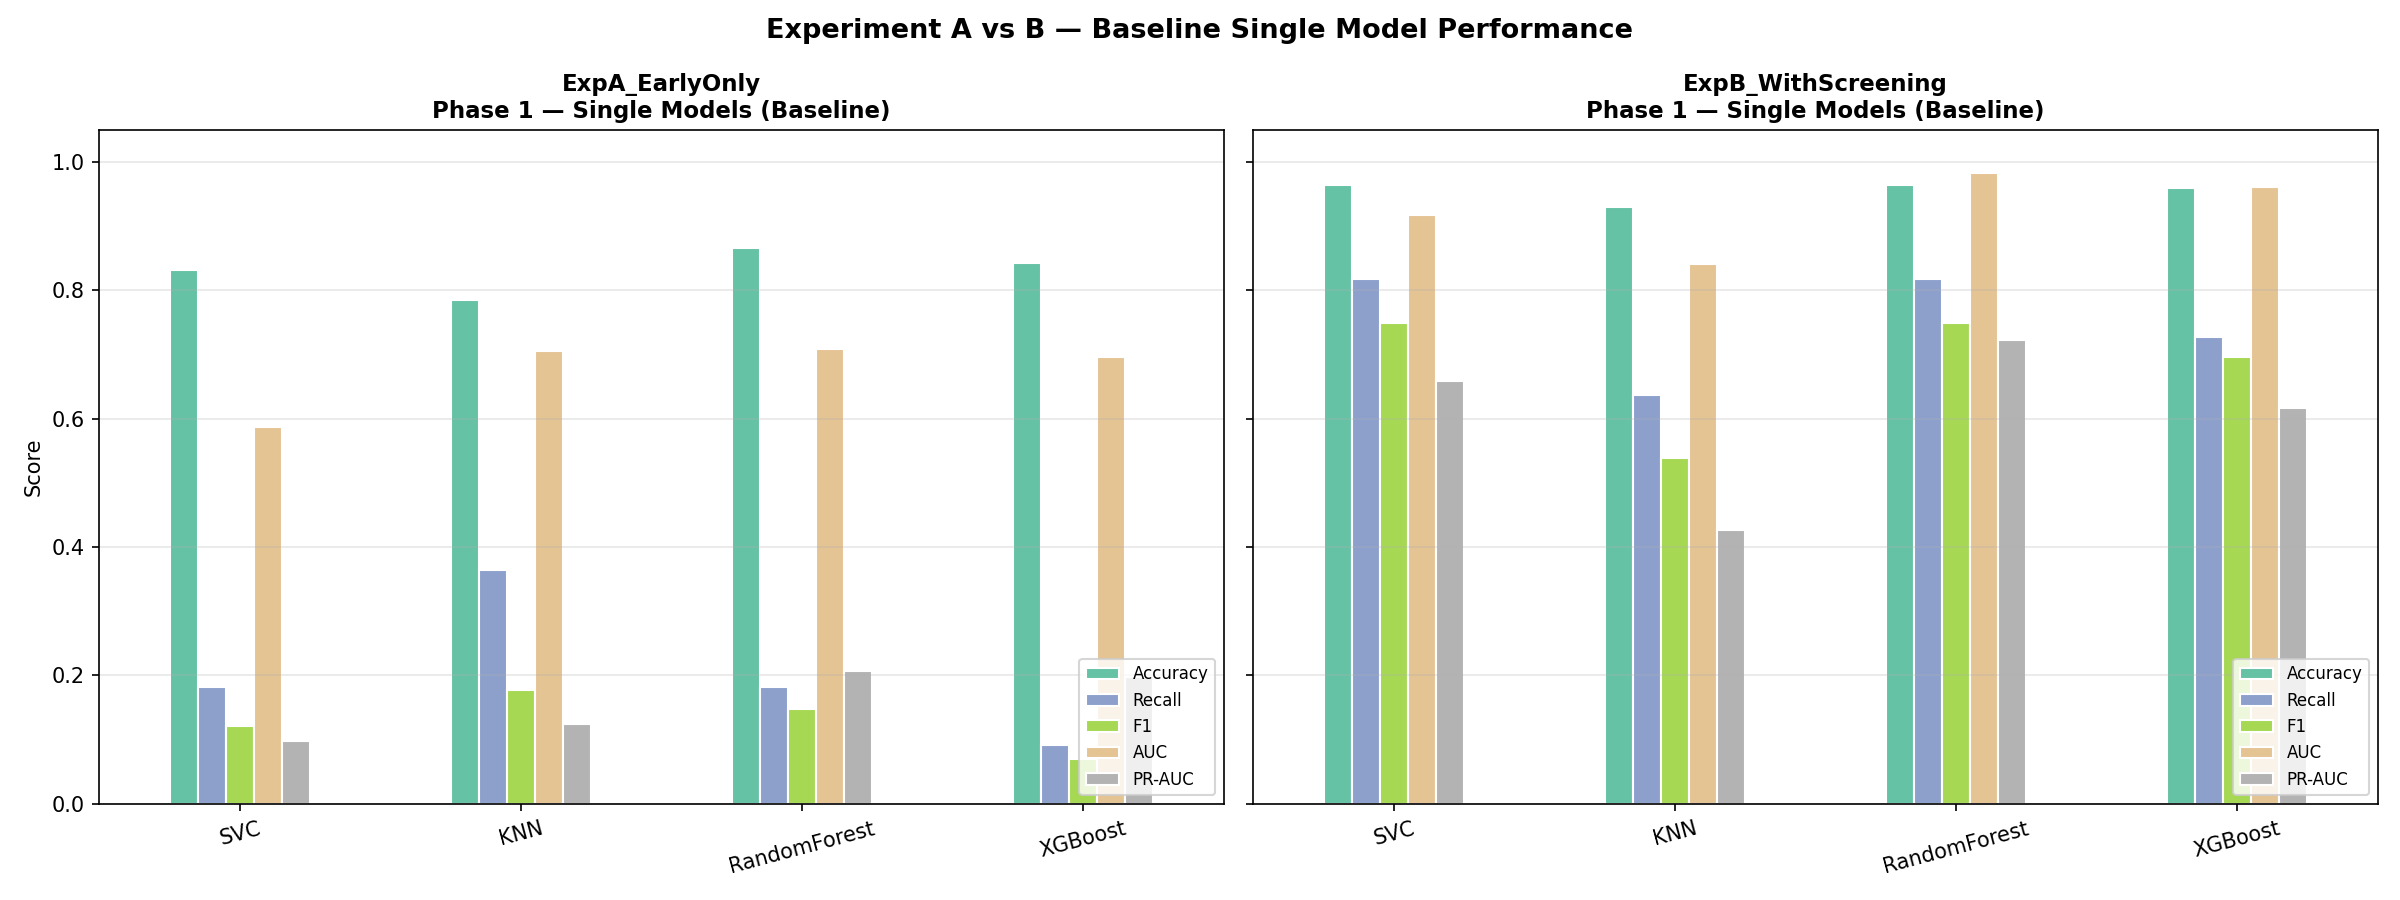

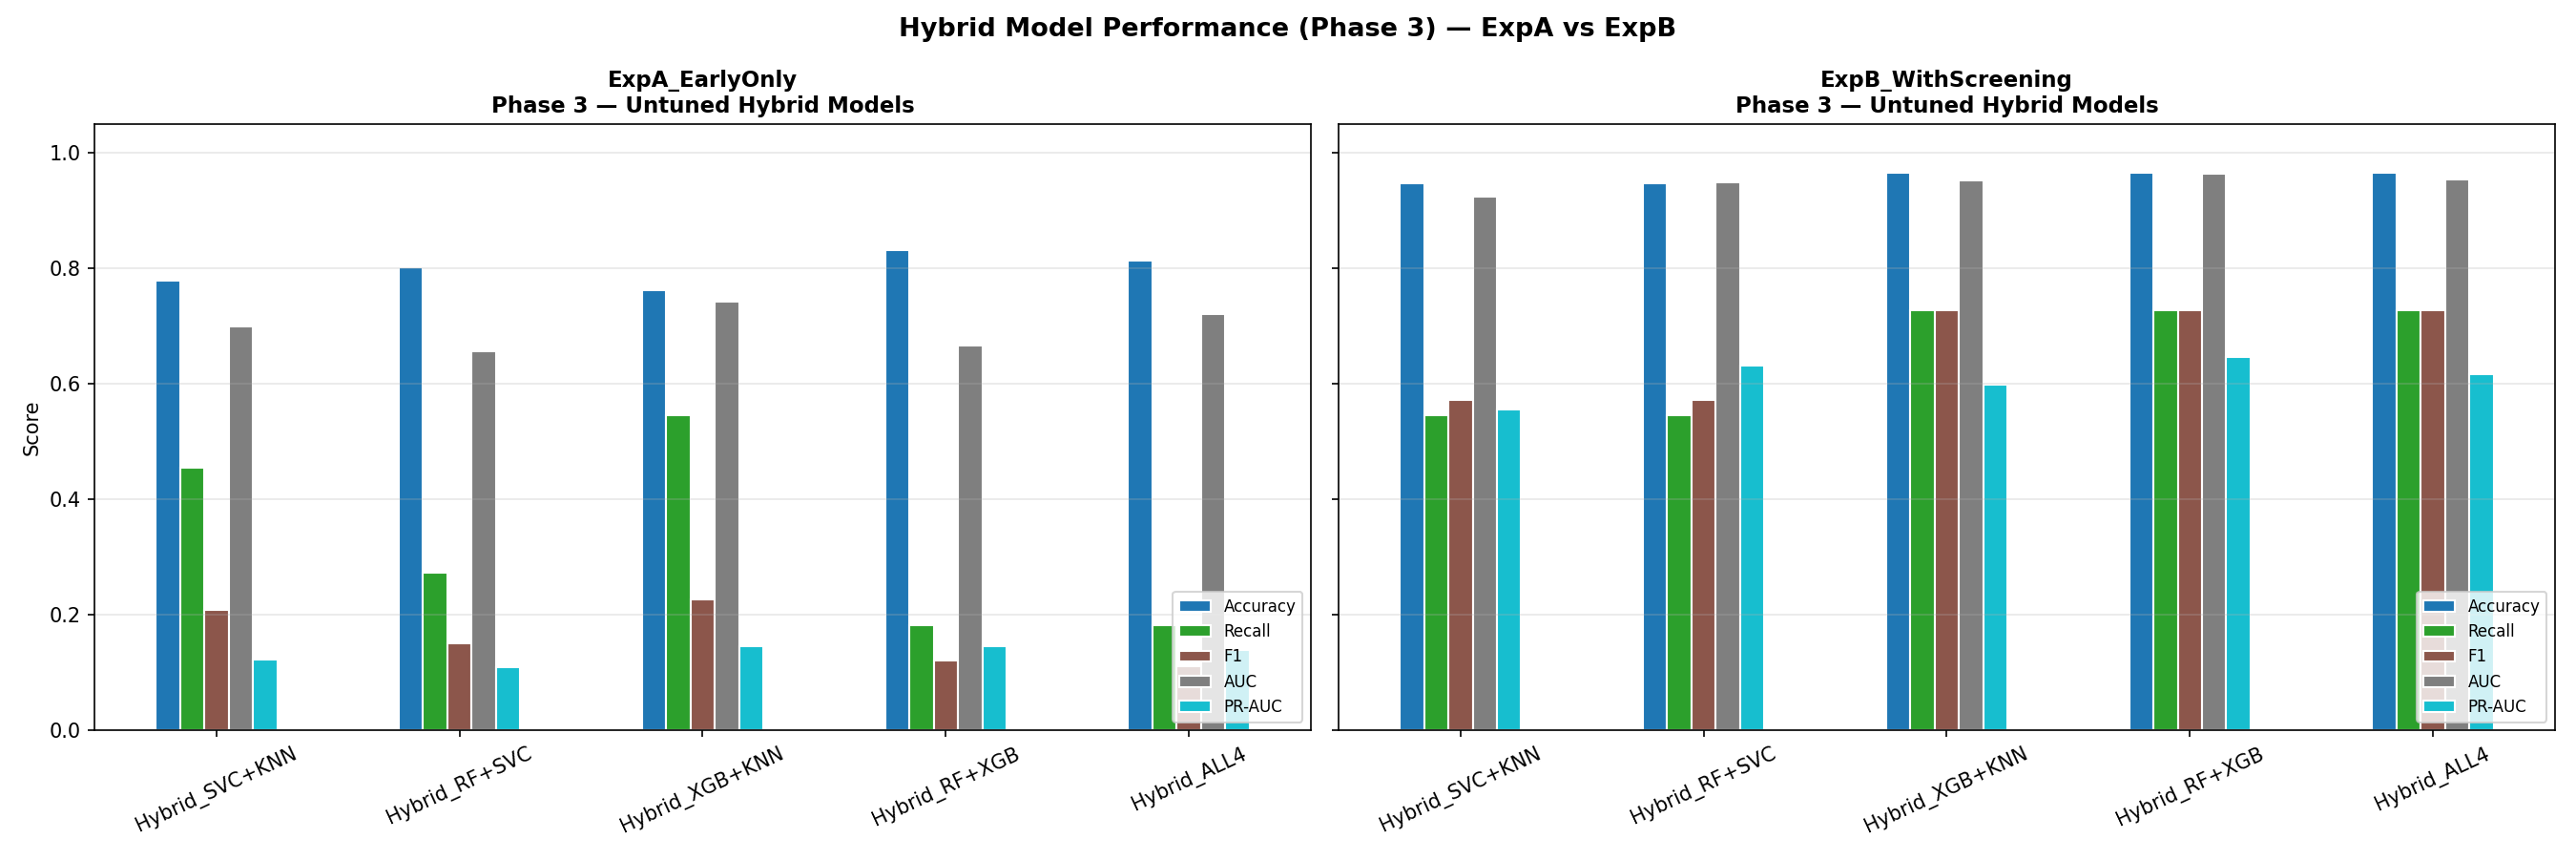

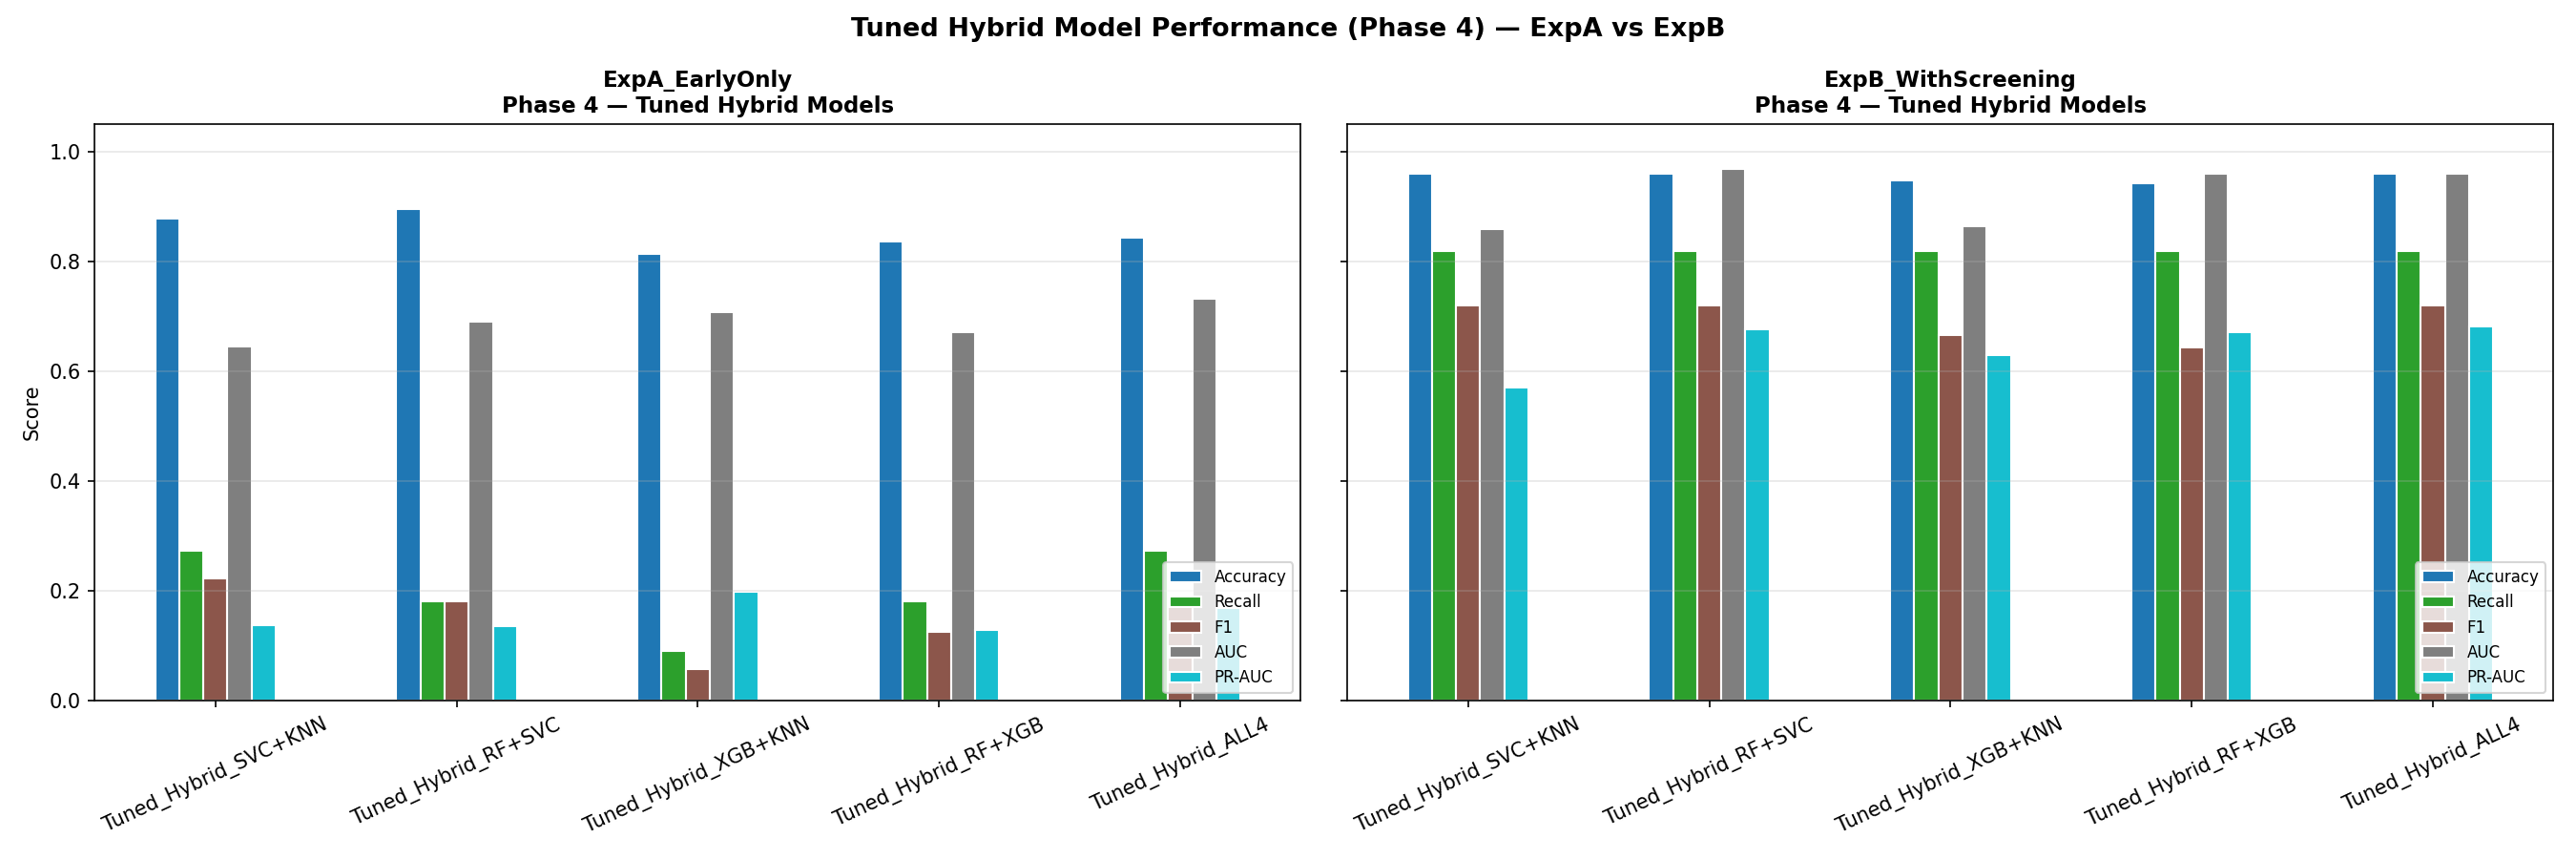

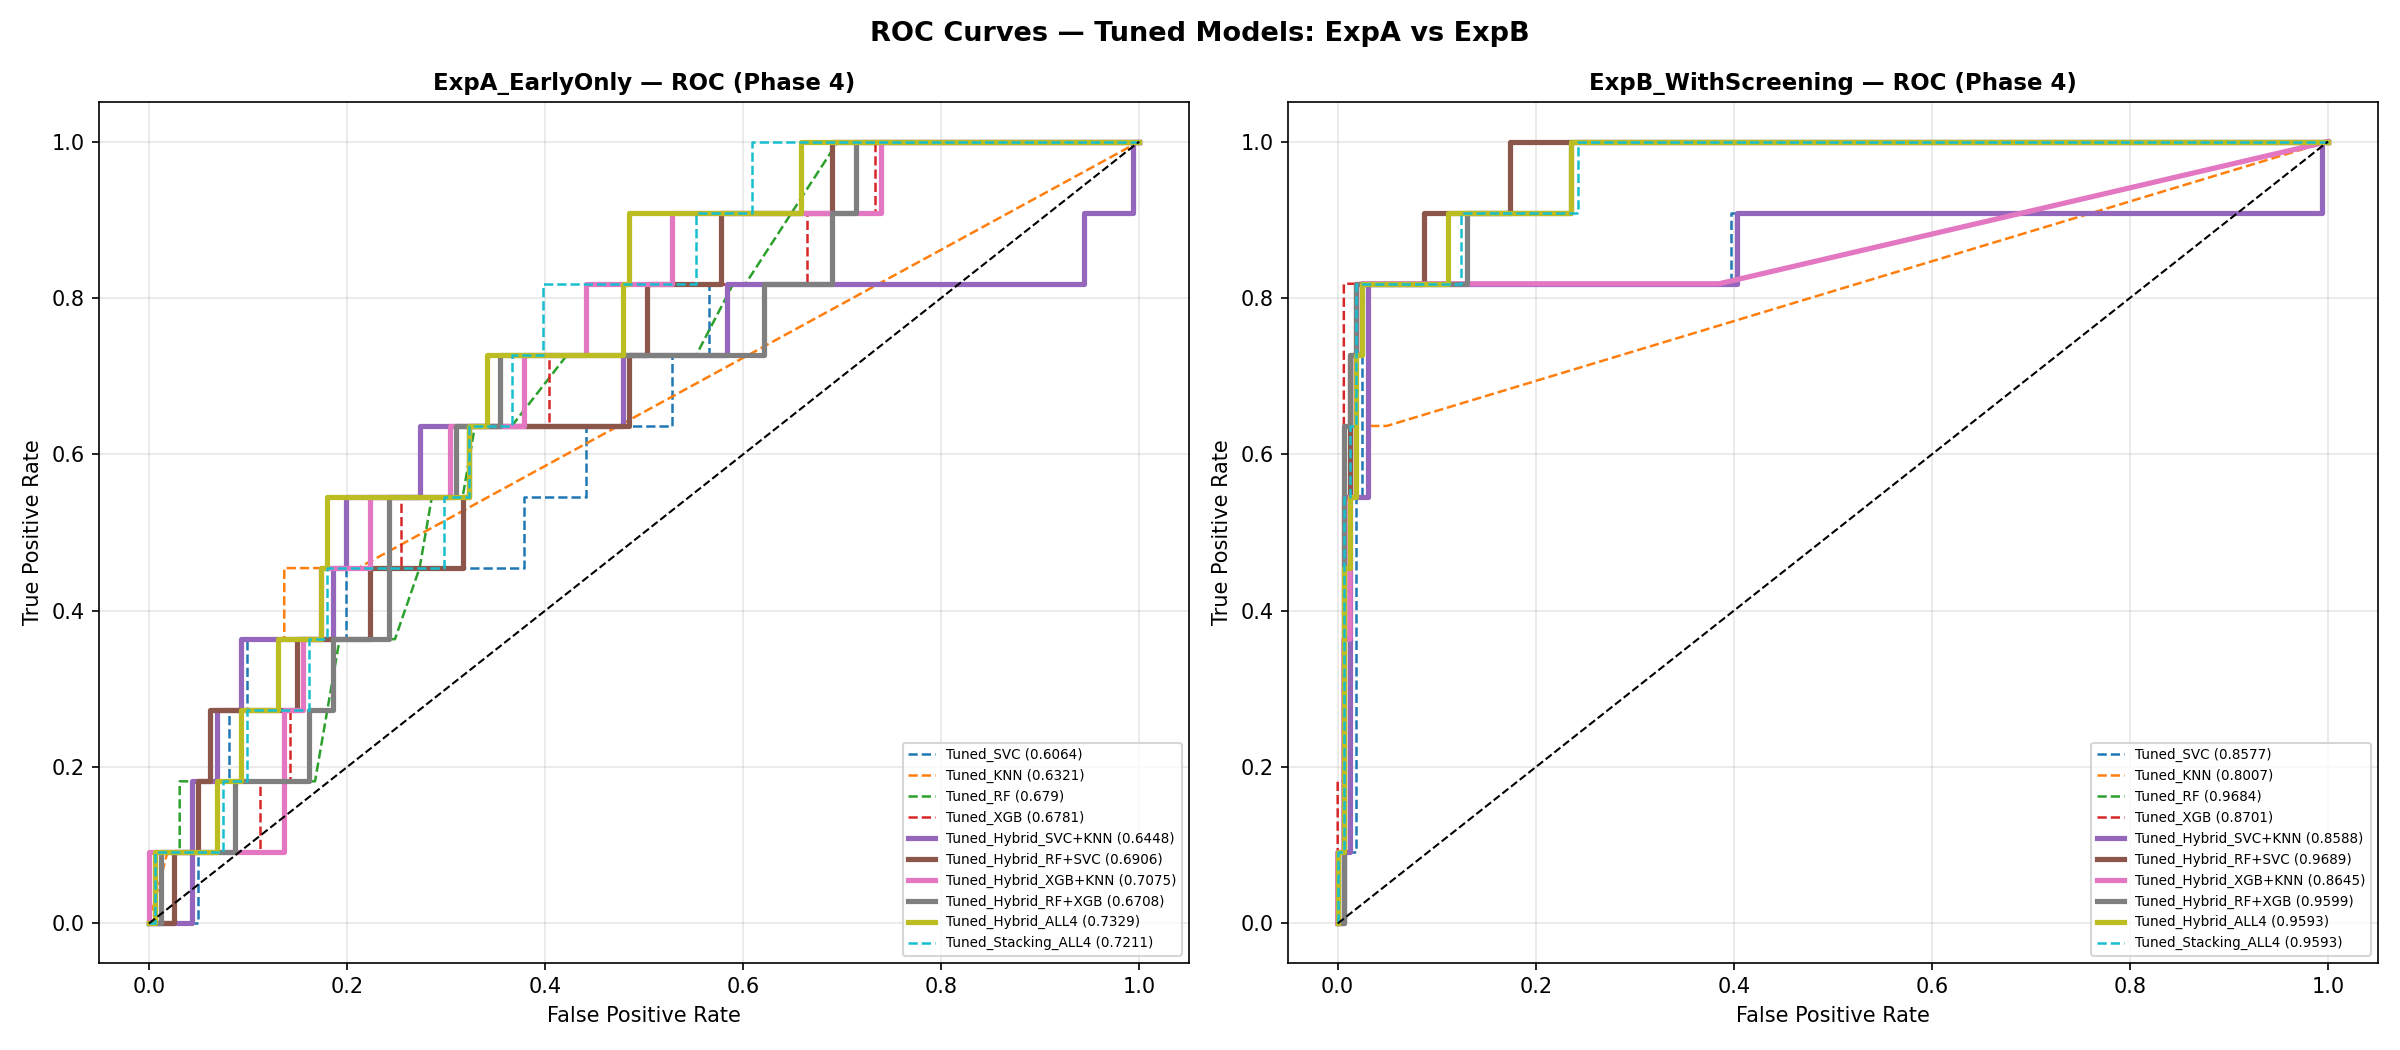

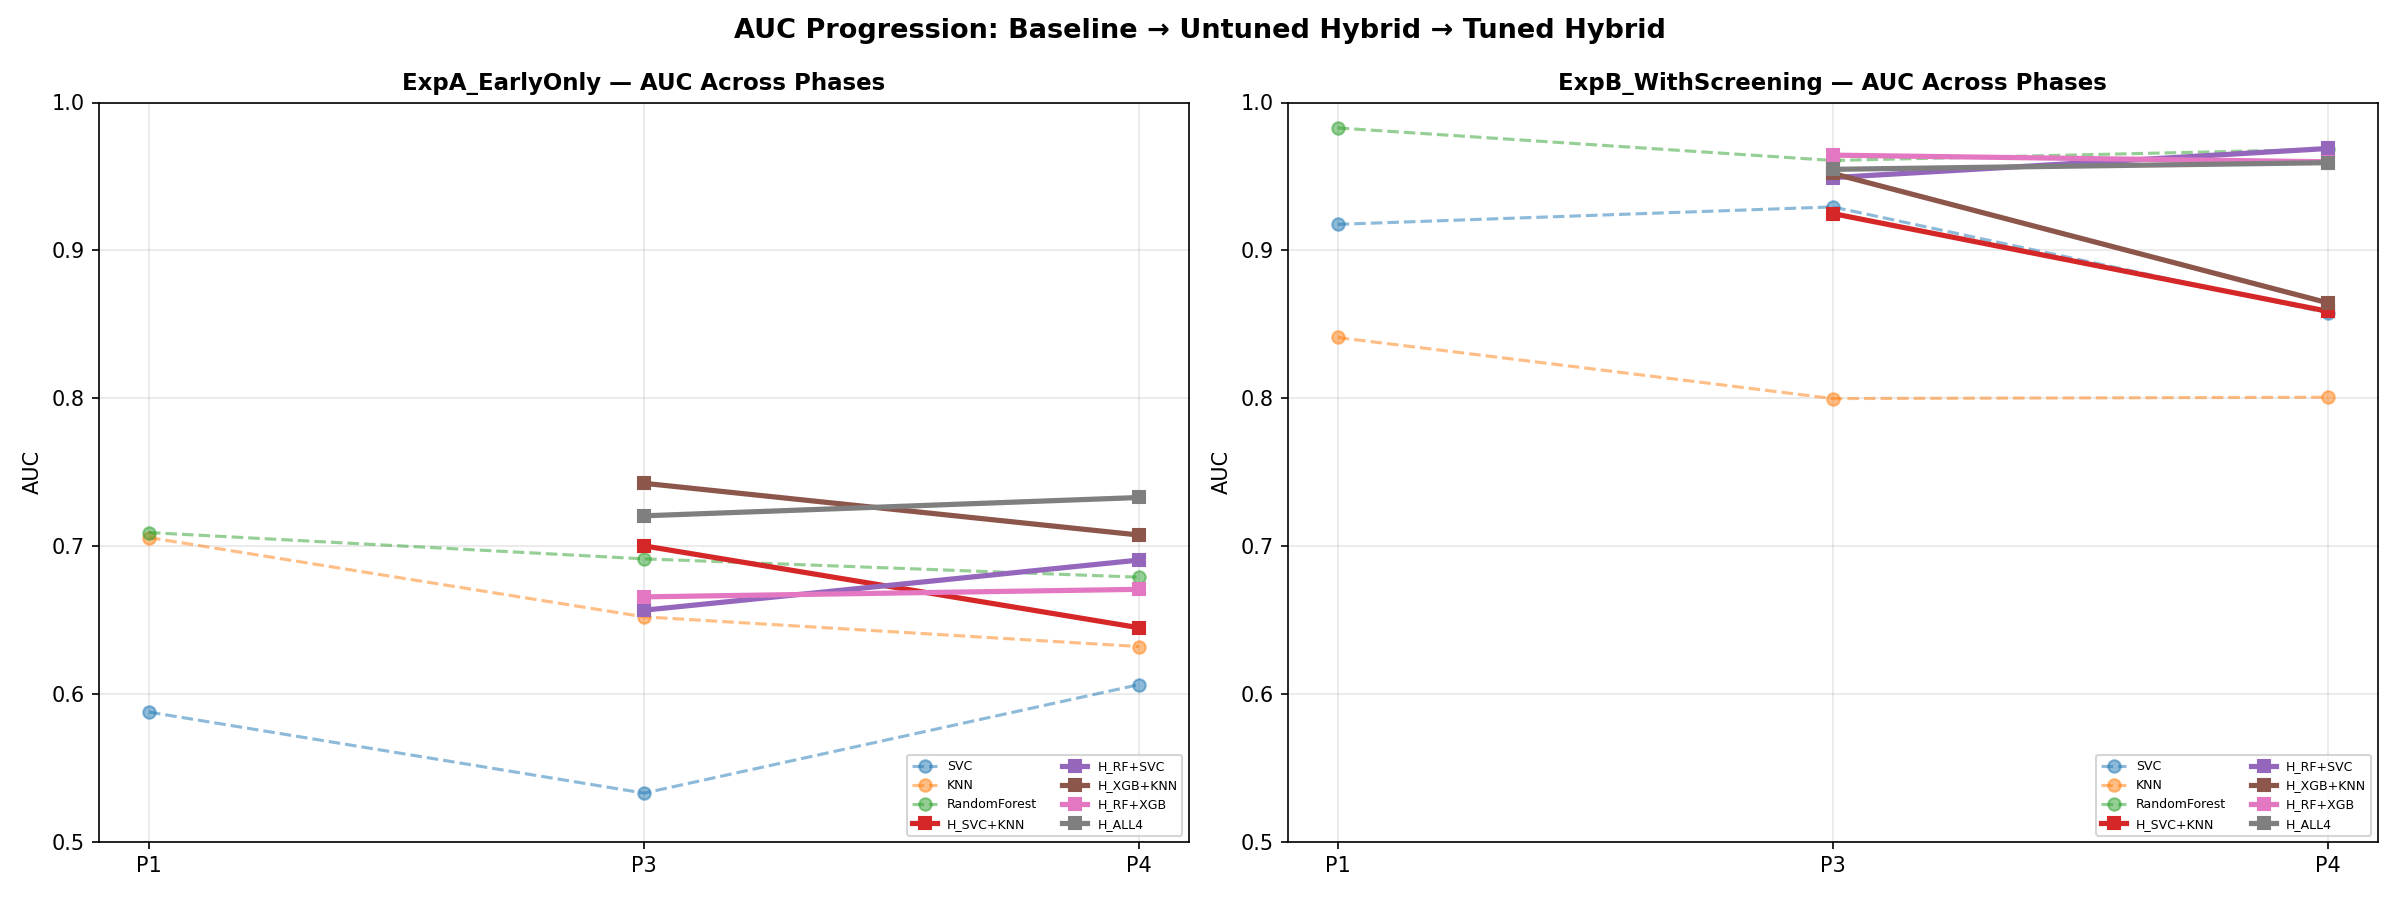

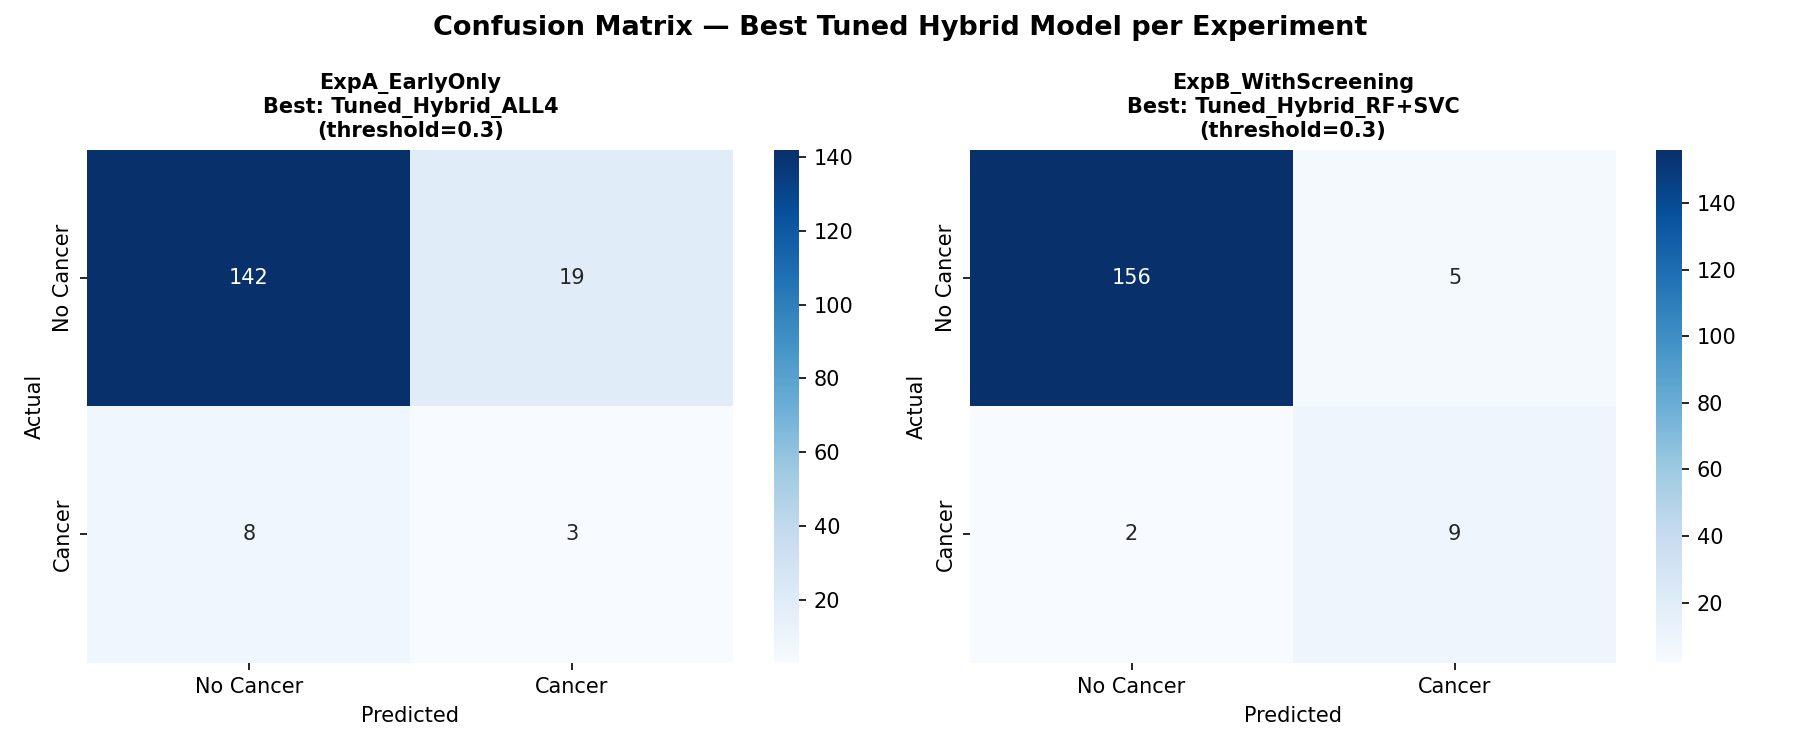

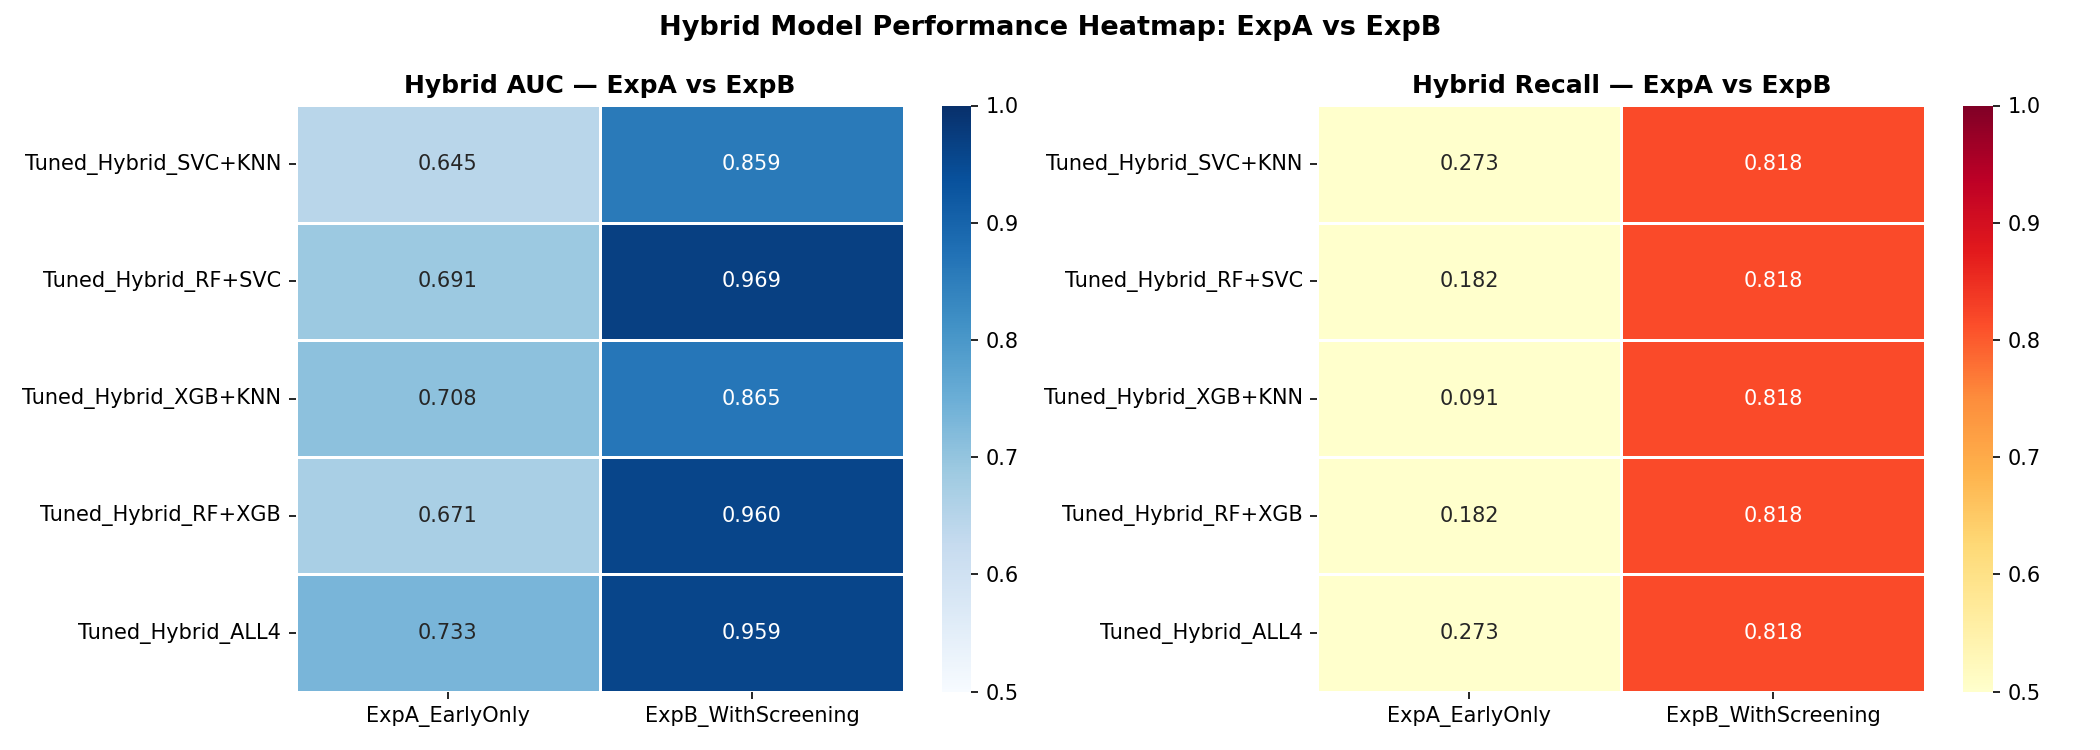

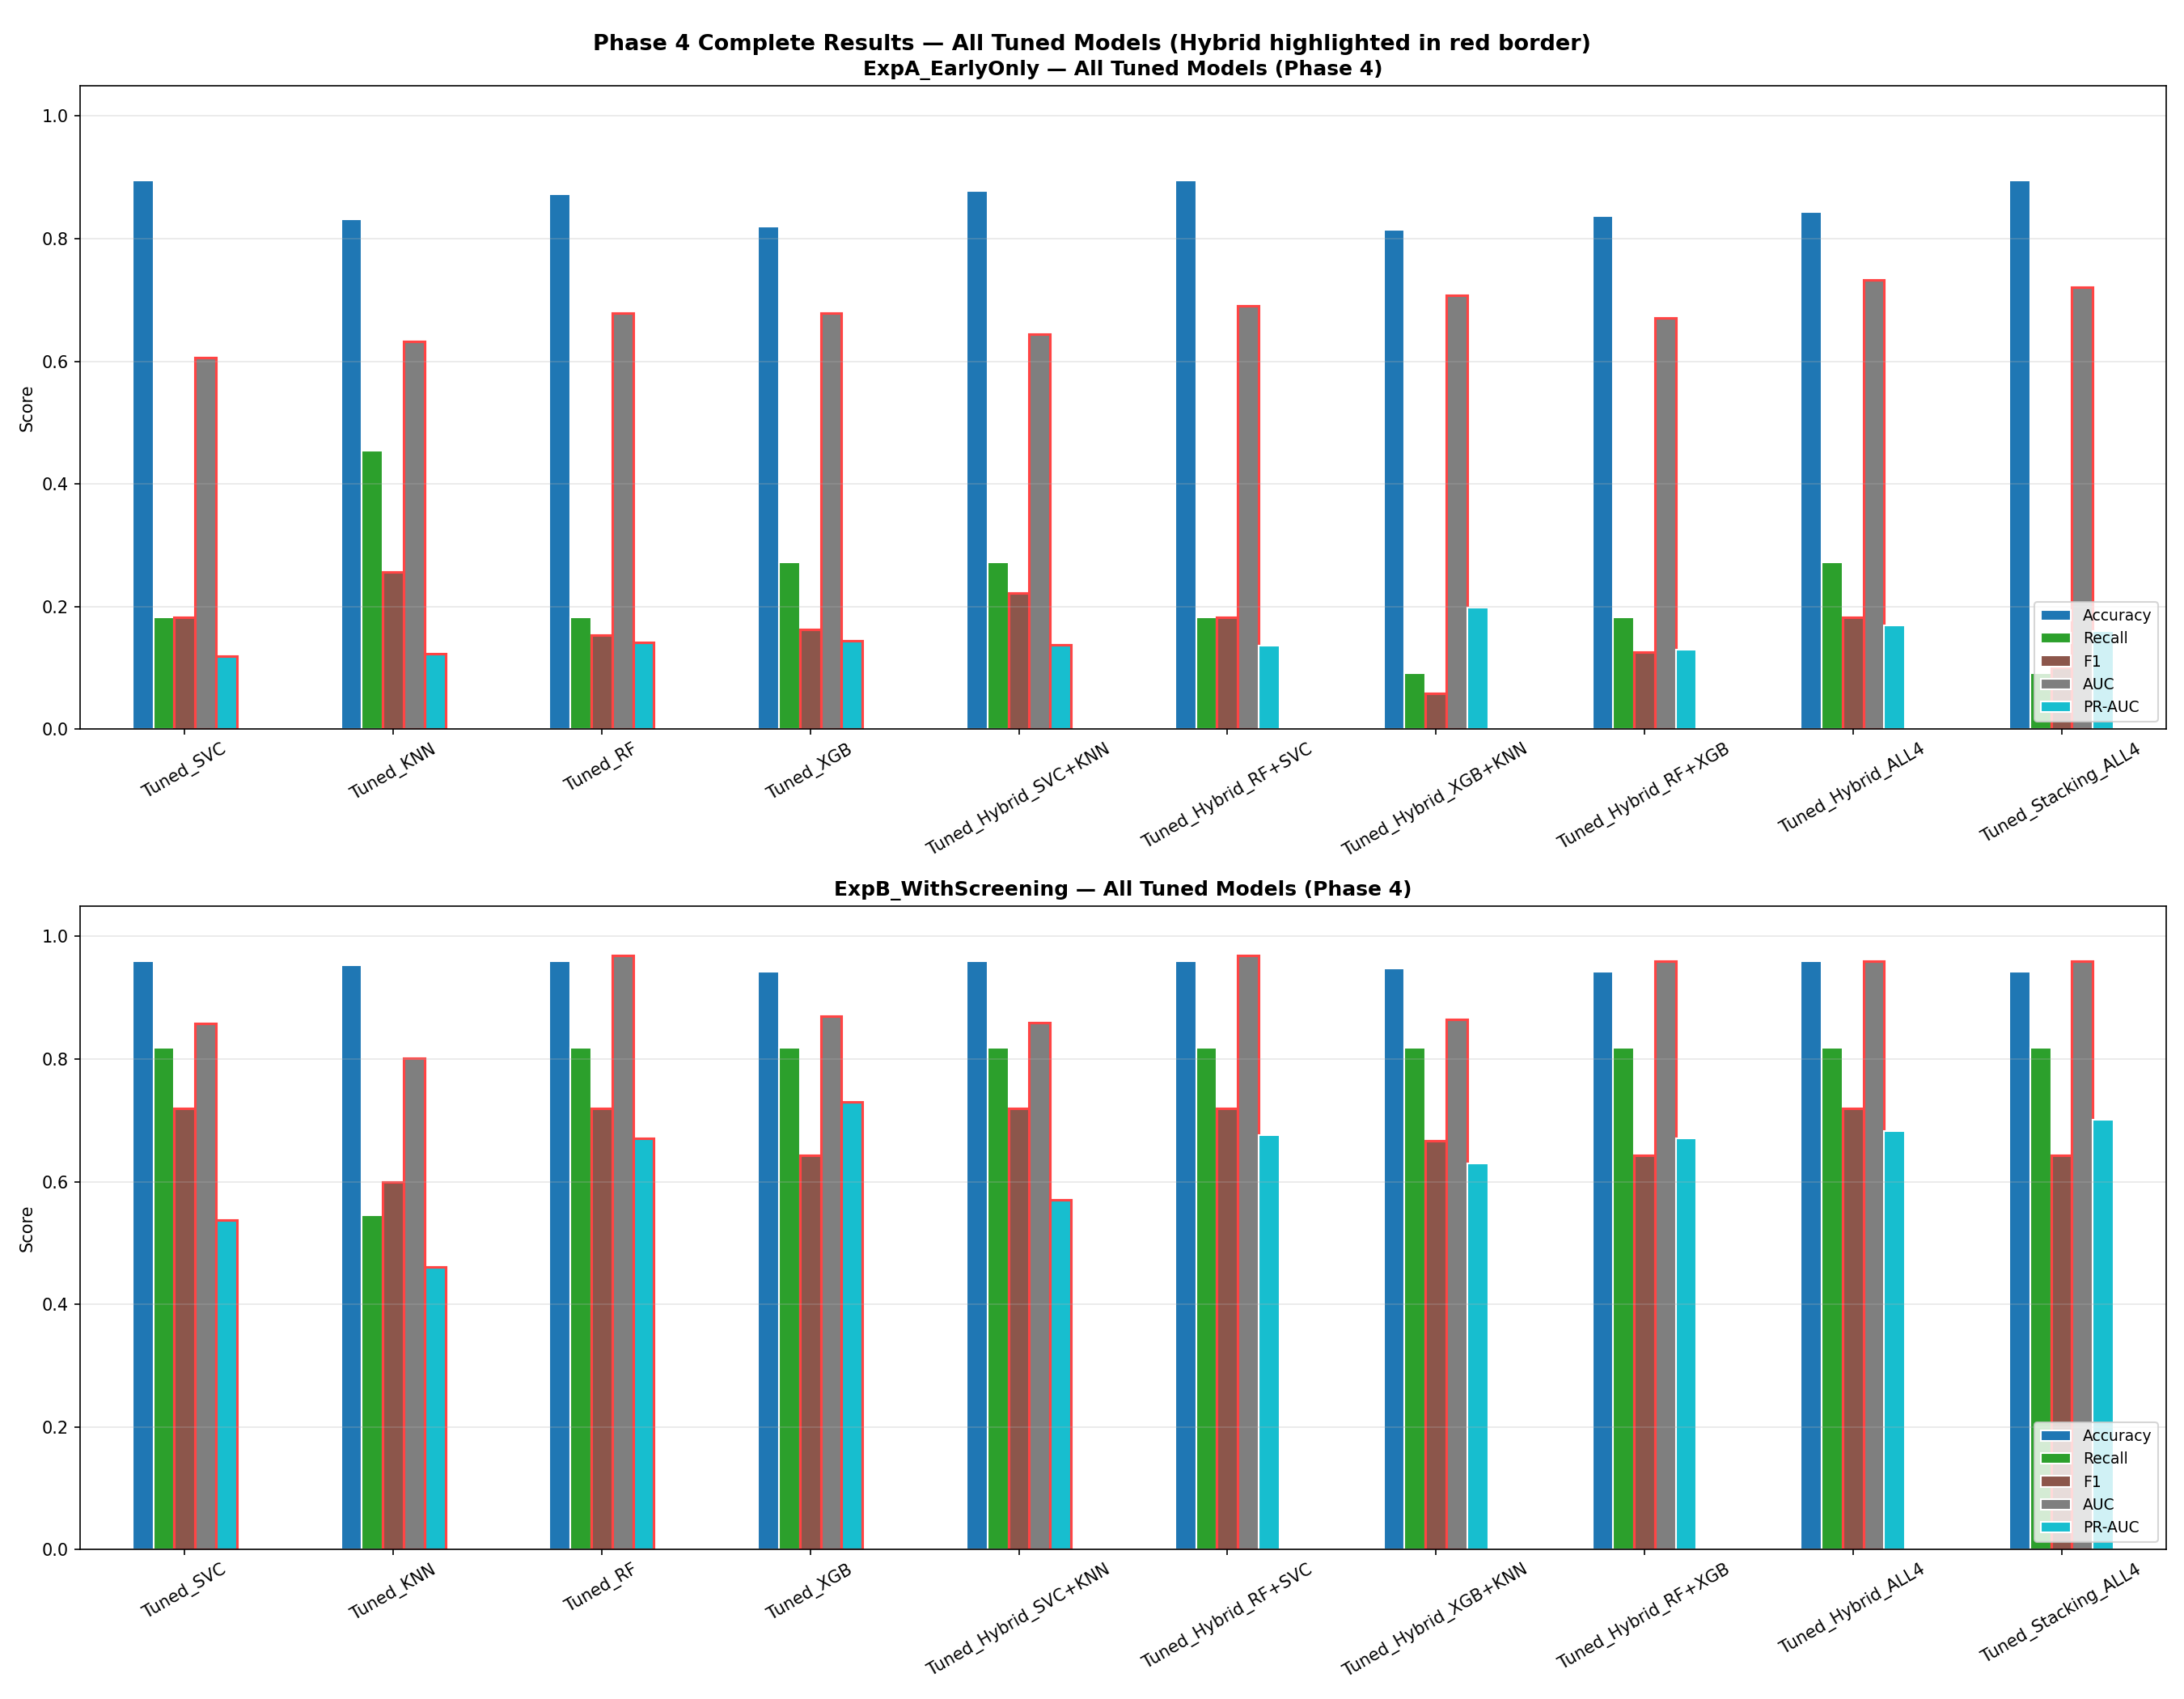

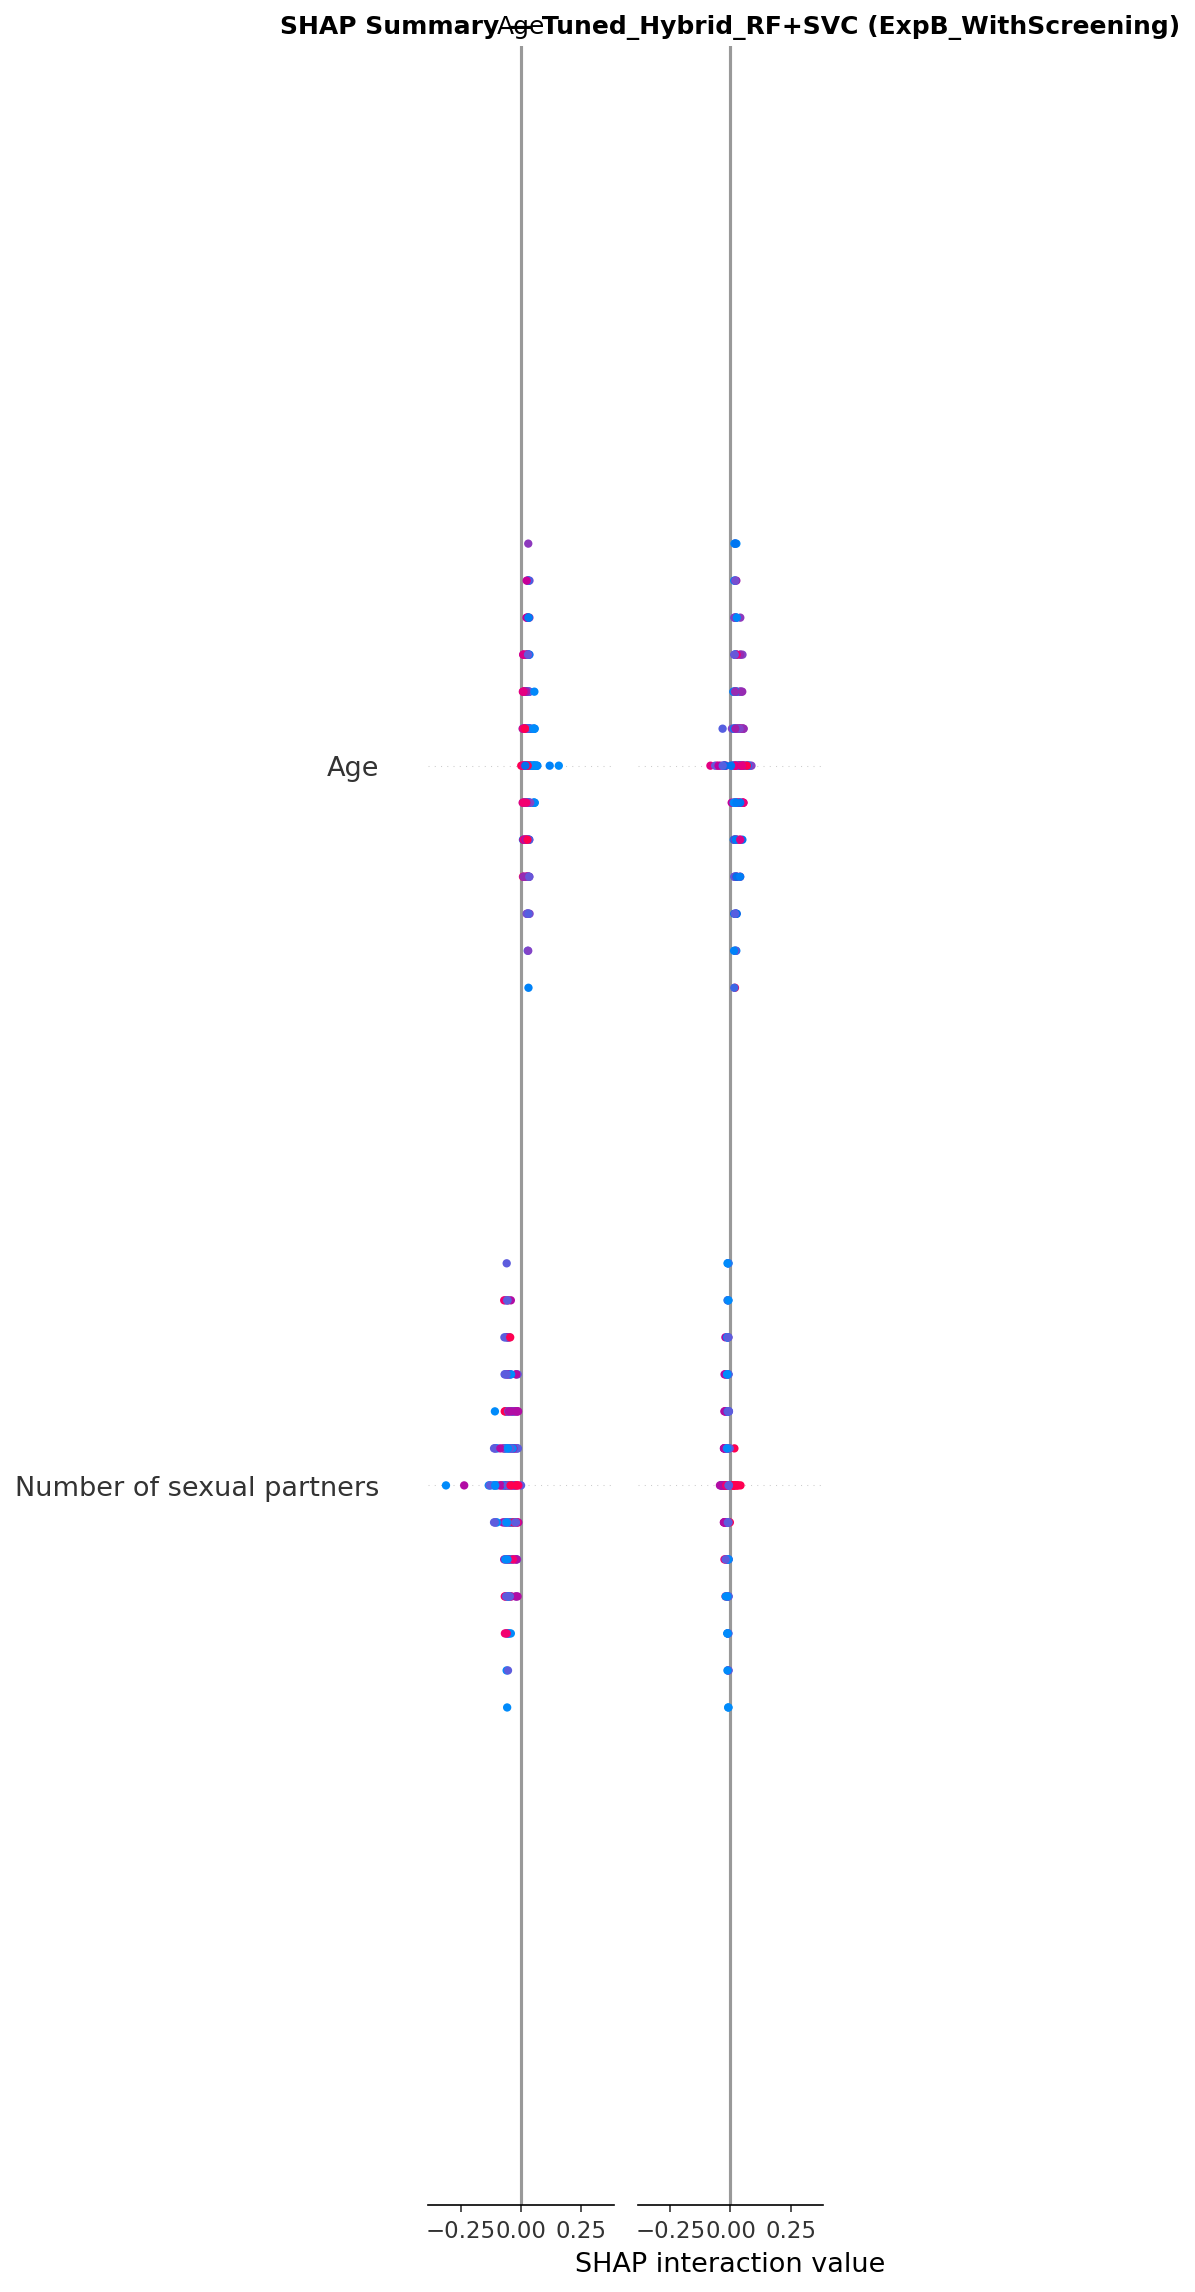

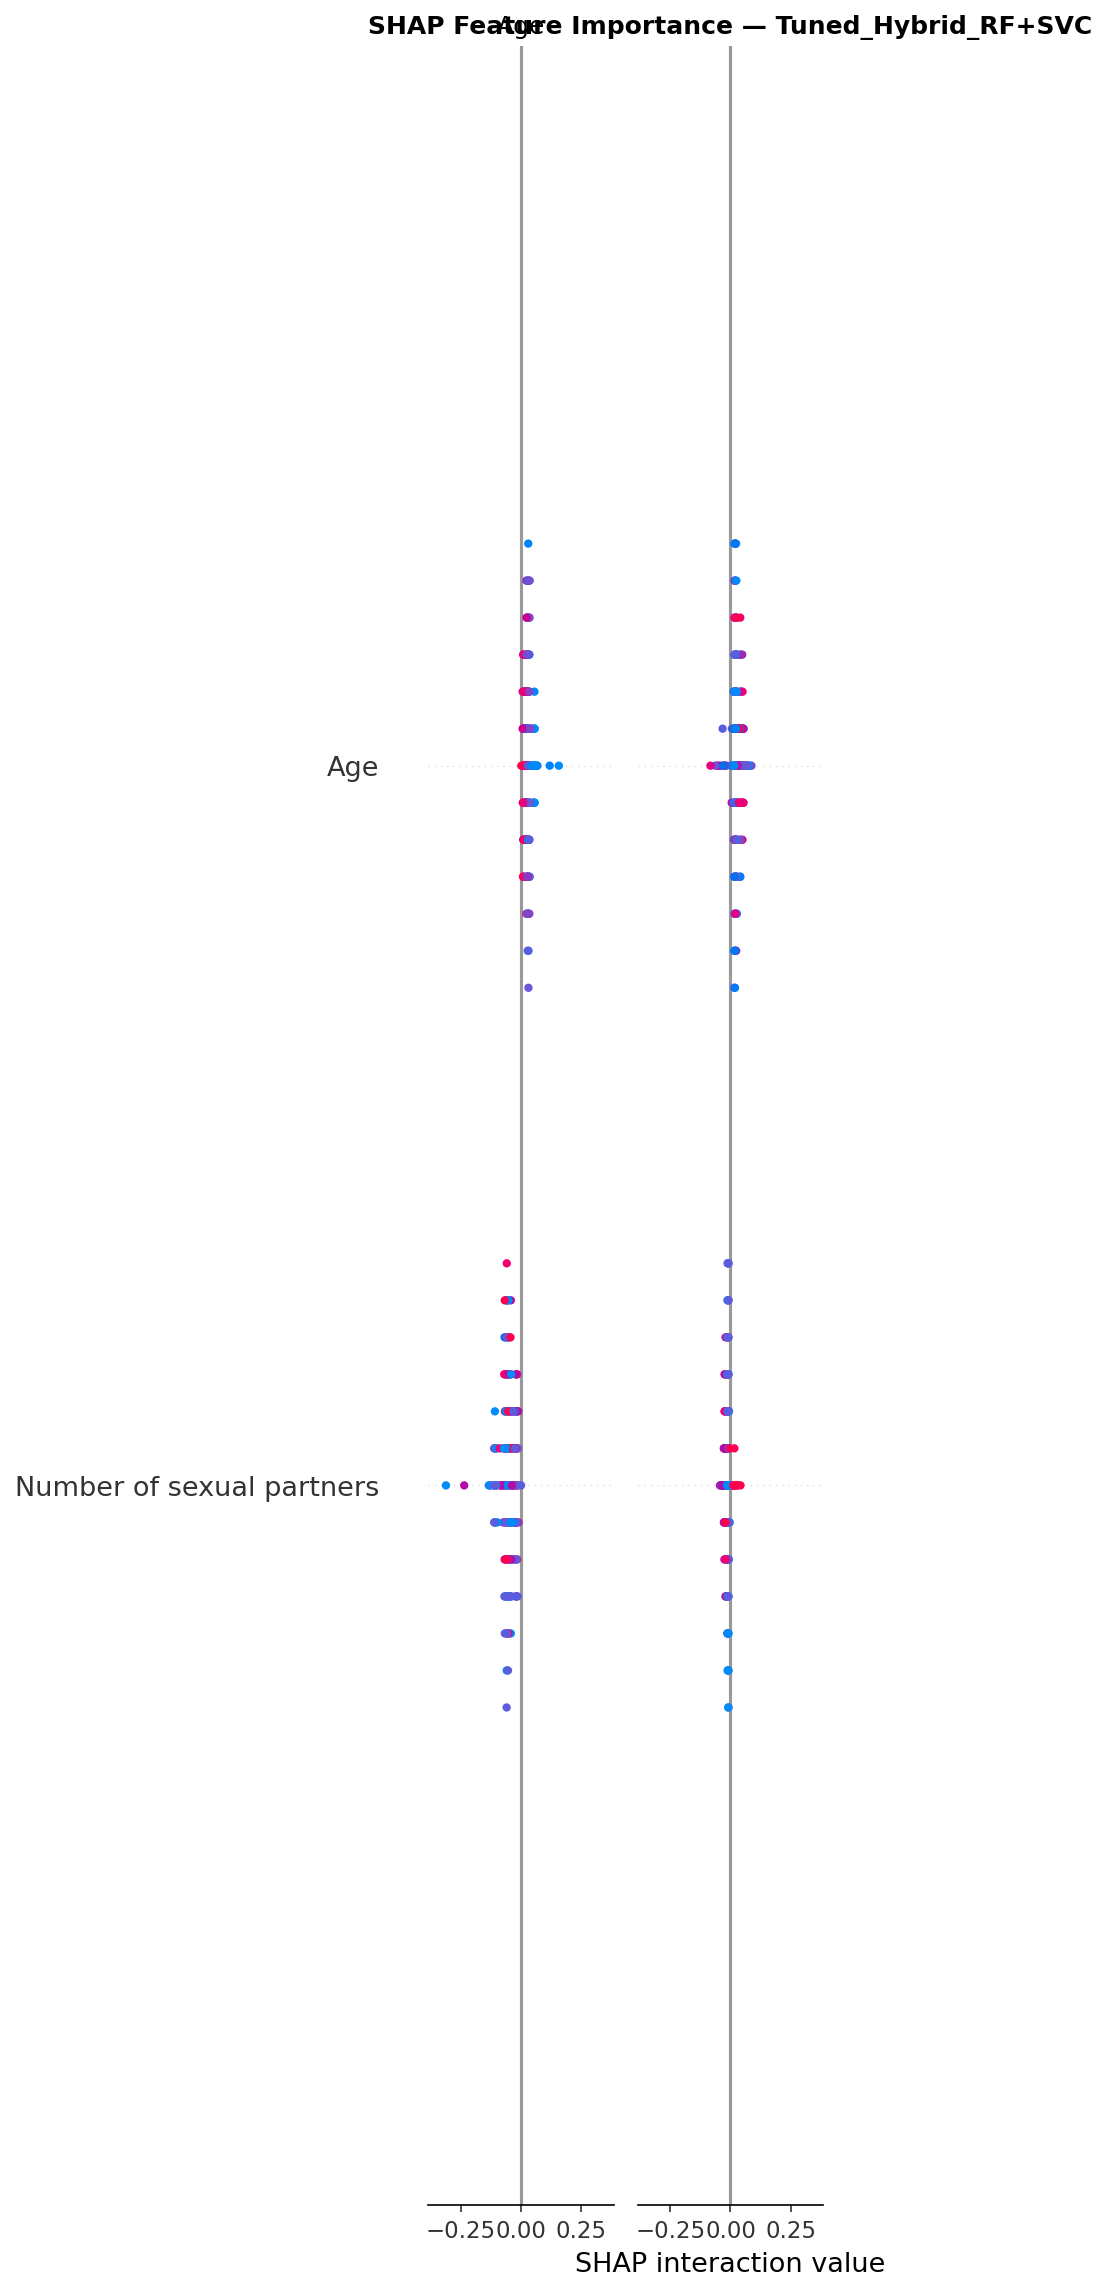

In [19]:
print_section("PIPELINE COMPLETE")
print("""
  Output files:
  ┌─ Data / CSV
  │   final_summary_ExpA_EarlyOnly.csv
  │   final_summary_ExpB_WithScreening.csv
  │   comparison_best_hybrid_expA_vs_expB.csv
  │
  ├─ Feature Importance
  │   feature_importance_ExpA_EarlyOnly.png
  │   feature_importance_ExpB_WithScreening.png
  │
  ├─ Visualizations
  │   viz1_expA_vs_expB_baseline.png          ← Phase 1 baseline comparison
  │   viz1a_threshold_curves_<exp>.png        ← Recall/Precision vs threshold
  │   viz1b_radar_comparison_<exp>.png        ← Multi-metric radar chart
  │   viz2_phase3_hybrid_comparison.png       ← Untuned hybrid performance
  │   viz3_phase4_tuned_hybrid_comparison.png ← Tuned hybrid performance
  │   viz4_roc_tuned_expA_vs_expB.png         ← ROC curves (Phase 4)
  │   viz5_auc_progression.png               ← AUC trend P1→P3→P4
  │   viz6_confusion_matrices.png            ← Confusion matrix (threshold=0.3)
  │   viz7_hybrid_heatmap_expA_vs_expB.png   ← AUC/Recall heatmap
  │   viz8_phase4_full_both_experiments.png  ← Full Phase 4 overview
  │
  └─ SHAP (if shap installed)
      shap_summary_expB.png                  ← Beeswarm feature attribution
      shap_importance_expB.png               ← Mean |SHAP| bar chart
""")
from IPython.display import Image, display

image_files = [
    "viz1_expA_vs_expB_baseline.png",
    "viz2_phase3_hybrid_comparison.png",
    "viz3_phase4_tuned_hybrid_comparison.png",
    "viz4_roc_tuned_expA_vs_expB.png",
    "viz5_auc_progression.png",
    "viz6_confusion_matrices.png",
    "viz7_hybrid_heatmap_expA_vs_expB.png",
    "viz8_phase4_full_both_experiments.png",
    "shap_summary_expB.png",
    "shap_importance_expB.png",
]

print("Displaying generated visualization files inline:")
for img in image_files:
    if os.path.exists(img):
        display(Image(filename=img))
    else:
        print(f"  Missing: {img}")